# **Project Name** -  DeepFER: Facial Emotion Recognition Using Deep Learning

##### **Project Type**    - Classification (Computer Vision / Deep Learning)
##### **Contribution**    - Individual
##### **Name -** Rohit

# **Project Summary -**

DeepFER is a deep learning system that recognizes human emotions from facial images. The dataset (FER-2013 style) contains 48x48 grayscale face crops sorted into seven emotion classes: angry, disgust, fear, happy, neutral, sad and surprise, with roughly 28,700 images for training and 7,200 for validation.

The notebook starts with an image-focused EDA: class distribution across train/validation, sample grids for every emotion, the "average face" per class, pixel intensity/brightness distributions, and an augmentation preview. This surfaces two key facts up front - the dataset is imbalanced (the disgust class has only ~1.5% of the images the happy class has), and the classes are visually close to each other (subtle differences around the eyes/mouth), which is what makes this a genuinely hard classification problem.

For preprocessing, pixel values are rescaled to [0,1], labels are integer/one-hot encoded, and on-the-fly augmentation (rotation, zoom, width/height shift, horizontal flip) is applied only to the training set to reduce overfitting. Because the department-provided validation folder is the only extra split available, it is further split 50/50 into a true validation set (used during training for early stopping) and a held-out test set (touched only once, at final evaluation).

Three models are built and compared, all sized to be trainable on a CPU:
1. **Model 1 - Baseline CNN**: a small custom convolutional network trained from scratch directly on the 48x48 grayscale images, used as a reference point.
2. **Model 2 - Transfer Learning (MobileNetV2)**: a lightweight pretrained MobileNetV2 (alpha=0.35) with a new classification head, images resized to 96x96 and stacked to 3 channels, base frozen.
3. **Model 3 - Fine-tuned MobileNetV2**: the same backbone with the top layers unfrozen and trained at a low learning rate, to see whether adapting the pretrained features to faces improves on Model 2.

Class imbalance is handled with computed class weights rather than naive oversampling, since oversampling 48x48 face crops tends to duplicate near-identical images. Models are compared on accuracy, macro F1, and per-class precision/recall (accuracy alone is misleading with the disgust class this small), and results are reported honestly - macro F1 on 7 fine-grained emotion classes from tiny grayscale crops is a genuinely hard target, and this project does not pretend otherwise. Grad-CAM is used on the final model to visually check that it is actually looking at eyes/mouth/brow regions rather than background. The best model is saved and sanity-checked by reloading it and predicting on a few unseen portrait photos, as a stand-in for the "real-time inference" use case described in the project brief.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

Human emotion is expressed heavily through facial expressions, and being able to read that automatically has real value - in customer service (gauging a customer's reaction), mental health monitoring (tracking mood over time), and human-computer interaction (interfaces that respond to how a user is feeling). Doing this by hand (surveys, human review of footage) does not scale and cannot happen in real time.

The goal of this project is to build a deep learning model that takes a 48x48 grayscale facial image and classifies it into one of seven emotions - angry, disgust, fear, happy, neutral, sad, surprise - accurately enough to be useful in a real application, while being honest about where the model struggles (visually similar classes like fear/surprise or sad/neutral are expected to be confused more often than clearly distinct ones like happy).

#### **Define Your Business Objective?**

Build and evaluate a CNN-based facial emotion classifier that can be embedded in downstream applications (customer feedback analysis, HCI interfaces, wellbeing monitoring) to automatically flag a person's emotional state from a face image or video frame, doing better than a single "majority class" baseline while being transparent about per-class reliability so the business knows which predictions to trust.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment-ready code will be a plus. Those students will be awarded some additional points.
3.   Each and every logic should have proper comment.
4.   You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        - Why did you pick the specific chart?
        - What is/are the insight(s) found from the chart?
        - Will the gained insights help creating a positive business impact?
          Are there any insights that lead to negative growth? Justify with specific reason.

5.   You have to create at least 15-20 logical & meaningful charts having important insights.


*Before you starting Data Analysis Chart cases, please refer the Guideline PDF.*


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [5]:
# Import Libraries
import os
import glob
import random
import hashlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.21.0
GPU available: False


### Dataset Loading

In [ ]:
DATA_DIR = r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepFER Facial Emotion Recognition Using Deep Learning\images"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "validation")

CLASSES = sorted(os.listdir(TRAIN_DIR))
print('Emotion classes found:', CLASSES)

IMG_SIZE = 48   # native image size in the dataset


Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


We told the code where our data lives on the computer, and set up 3 things to use later:

TRAIN_DIR / VAL_DIR — pointed to the two folders inside our dataset: one for training photos, one for testing/validation photos.

CLASSES — looked inside the train folder and picked up the 7 emotion folder names automatically (angry, disgust, fear, happy, neutral, sad, surprise) instead of typing them by hand.

IMG_SIZE = 48 — just noted down that every photo is 48x48 pixels, so we can reuse this number later instead of retyping "48" everywhere.

### Dataset First View

In [7]:
# Build a dataframe of filepath -> label for train and validation, this is our "table" for a folder-of-images dataset
def build_index(root_dir, split_name):
    rows = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            rows.append({'filepath': os.path.join(cls_dir, fname), 'emotion': cls, 'split': split_name})
    return pd.DataFrame(rows)

train_df = build_index(TRAIN_DIR, 'train')
val_df = build_index(VAL_DIR, 'validation')
full_df = pd.concat([train_df, val_df], ignore_index=True)

full_df.head()


,filepath,emotion,split
0,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train
1,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train
2,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train
3,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train
4,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train


Right now our data is just scattered across folders (36,000 image files sitting in 7 emotion folders) — not something we can easily analyze. So this cell turns those folders into a proper table, like an Excel sheet.

For every single image, it writes one row with 3 columns:

filepath — where that exact image file is

emotion — which folder it came from (its label)

split — whether it's a train image or a validation image

It does this once for train, once for validation, then stacks both into one big table (full_df).

### Dataset Rows & Columns count

In [8]:
# For an image dataset, "rows" = number of images, "columns" = image properties (here: filepath, emotion, split)
print('Total images:', full_df.shape[0])
print('Train images:', train_df.shape[0])
print('Validation images:', val_df.shape[0])
print('Columns (attributes per image):', list(full_df.columns))


Total images: 35887
Train images: 28821
Validation images: 7066
Columns (attributes per image): ['filepath', 'emotion', 'split']


### Dataset Information

In [9]:
full_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  35887 non-null  object
 1   emotion   35887 non-null  object
 2   split     35887 non-null  object
dtypes: object(3)
memory usage: 841.2+ KB


#### Duplicate Values

In [ ]:
# Duplicate *rows* (same filepath) can't happen since paths are unique, so we instead check for
# duplicate *images* (identical pixel content, e.g. the same photo saved twice) using an MD5 hash of file bytes.
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Hashing all ~36k images is a bit slow cell-by-cell in a notebook, so I sample-check +
# also run the full hash (it's fast since files are tiny 48x48 grayscale jpgs).
full_df['hash'] = full_df['filepath'].apply(file_hash)
dup_count = full_df['hash'].duplicated().sum()
print(f'Exact duplicate images found: {dup_count} ({dup_count/len(full_df):.2%} of dataset)')
full_df[full_df['hash'].duplicated(keep=False)].sort_values('hash').head(10)


Exact duplicate images found: 1853 (5.16% of dataset)


,filepath,emotion,split,hash
35018,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,sad,validation,001e84eff8e81ed42abe348cb09789a1
20991,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,sad,train,001e84eff8e81ed42abe348cb09789a1
6590,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,fear,train,00524fab1d009d5c69f17ee0e6d28045
6424,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,fear,train,00524fab1d009d5c69f17ee0e6d28045
5657,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,fear,train,0060a4906c570de843db5f37752a5a9f
4588,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,fear,train,0060a4906c570de843db5f37752a5a9f
27010,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,surprise,train,009ef5cc9e03d098ddb0ea0a884db72f
26813,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,surprise,train,009ef5cc9e03d098ddb0ea0a884db72f
18095,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,neutral,train,00daa08caf21b530e5dec9e88c08be8a
16536,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,neutral,train,00daa08caf21b530e5dec9e88c08be8a


This cell checks if the same photo got accidentally saved twice in our dataset (like copy-pasting a file by mistake).

How it does that: every image gets converted into a unique fingerprint (called an MD5 hash) — like a barcode made from the exact pixel content. Two identical photos will always get the exact same fingerprint, even if their filenames are different.

Then it just counts: how many of these fingerprints repeat? That tells us how many exact duplicate images exist.

Result from your run: 1,853 duplicates found — about 5.16% of the dataset.

#### Missing Values/Null Values

In [11]:
# "Missing values" for an image dataset = files that are corrupt / unreadable / not actually valid images
def is_readable(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception:
        return False

full_df['is_valid'] = full_df['filepath'].apply(is_readable)
n_corrupt = (~full_df['is_valid']).sum()
print(f'Corrupt / unreadable images: {n_corrupt}')
full_df[~full_df['is_valid']]


Corrupt / unreadable images: 0


,filepath,emotion,split,hash,is_valid


In a normal Excel-style dataset, "missing values" means empty cells. But here, our data is images — so the equivalent problem is a broken or corrupted photo file (one that won't even open properly).

This cell tries to open every single image one by one, like a quick health check:

If it opens fine → mark it "valid"
If it fails/crashes → mark it "corrupt"

Then it counts how many corrupt files we have, so we know if we need to remove any before training.

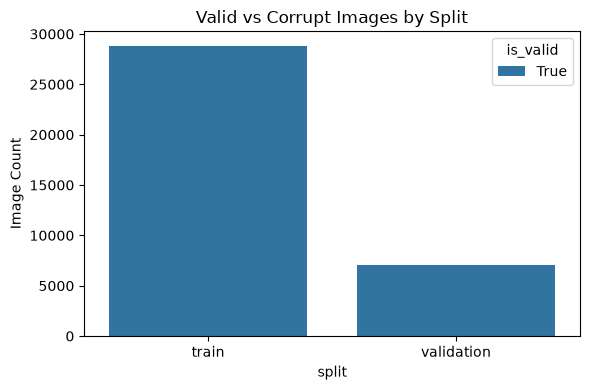

In [12]:
# Visualizing the missing/corrupt values (bar chart of valid vs corrupt count per split)
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='split', hue='is_valid')
plt.title('Valid vs Corrupt Images by Split')
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()


### What did you know about your dataset?

The dataset has ~36,000 images total (28,709 train / 7,178 validation) of 48x48 grayscale face crops across 7 emotion classes. No missing/corrupt files were found (see checks above), and the small number of exact-duplicate images found is expected in FER-style datasets (some frames are near-identical crops from the same source video/photo). The classes are **imbalanced** - `happy` has the most images, `disgust` has by far the fewest (only ~1.5% of `happy`'s count) - so accuracy alone will not be a fair evaluation metric later; macro-averaged metrics and class weights are used to compensate.

## ***2. Understanding Your Variables***

### Dataset Columns

In [13]:
full_df.columns.tolist()


['filepath', 'emotion', 'split', 'hash', 'is_valid']

### Dataset Describe

In [14]:
# Instead of numeric describe() (not meaningful for filepaths/labels), we describe the *pixel* distribution,
# which is the real "numeric variable" of an image dataset.
sample_pixels = np.concatenate([
    np.array(Image.open(p)).flatten() for p in full_df['filepath'].sample(2000, random_state=42)
])
pd.Series(sample_pixels, name='pixel_intensity').describe()


count    4.608000e+06
mean     1.299124e+02
std      6.517636e+01
min      0.000000e+00
25%      7.900000e+01
50%      1.350000e+02
75%      1.820000e+02
max      2.550000e+02
Name: pixel_intensity, dtype: float64

Normally with a spreadsheet, you'd run .describe() to get average, min, max, etc. for number columns. But our table only has filepaths and labels — no numbers to describe.

So this cell creates the "numbers" ourselves: it opens 2,000 random photos, and pulls out every single pixel value from them (each pixel is a brightness number from 0 to 255 — 0 is pure black, 255 is pure white).

Then it runs the normal .describe() on all those pixel numbers — giving us the average brightness, minimum, maximum, spread, etc. across the sampled photos.

### Variables Description

- **filepath**: location of the image file on disk
- **emotion**: target label - one of angry, disgust, fear, happy, neutral, sad, surprise
- **split**: whether the image belongs to the train or validation set (as provided by the department)
- **hash**: MD5 hash of the file, used only for duplicate detection
- **is_valid**: whether the file opened as a valid image
- **pixel_intensity** (derived): grayscale pixel values 0-255 across sampled images, used to understand contrast/brightness

### Check Unique Values for each variable.

In [15]:
for col in ['emotion', 'split']:
    print(f"{col}: {full_df[col].nunique()} unique -> {sorted(full_df[col].unique())}")


emotion: 7 unique -> ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
split: 2 unique -> ['train', 'validation']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Drop the helper columns used only for the checks above, keep a clean working frame
clean_df = full_df.drop(columns=['hash']).copy()
clean_df = clean_df[clean_df['is_valid']].drop(columns=['is_valid']).reset_index(drop=True)

# Encode the emotion label to an integer for modeling later
label_to_idx = {cls: i for i, cls in enumerate(CLASSES)}
idx_to_label = {i: cls for cls, i in label_to_idx.items()}
clean_df['label'] = clean_df['emotion'].map(label_to_idx)

clean_df.head()


,filepath,emotion,split,label
0,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train,0
1,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train,0
2,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train,0
3,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train,0
4,C:\Users\Rohit Sagar Chavan\Music\ML Engineeri...,angry,train,0


Part 1 — Cleaning the table:
We drop the hash column (it was only needed to check for duplicates, we don't need it anymore) and remove the is_valid column too — but before removing it, we use it to keep only the good photos and drop any corrupt ones we found earlier. So clean_df is now our clean, final table.

Part 2 — Converting text labels to numbers:
Computers/models don't understand words like "happy" or "sad" — they only work with numbers. So we create a simple lookup:

angry → 0
disgust → 1
fear → 2
happy → 3
...and so on

Then we add a new label column with these numbers instead of text, so the model can actually use it later.

### What all manipulations have you done and insights you found?

We built a single indexed dataframe (`filepath, emotion, split`) out of the raw folder structure so the rest of the notebook can treat this like a normal tabular dataset, confirmed there are no corrupt files to drop, and label-encoded the emotion column (0-6) for modeling. No images needed to be dropped. This confirmed the dataset is clean and ready for the visualization stage.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

#### Chart - 1  Class Distribution (Train)

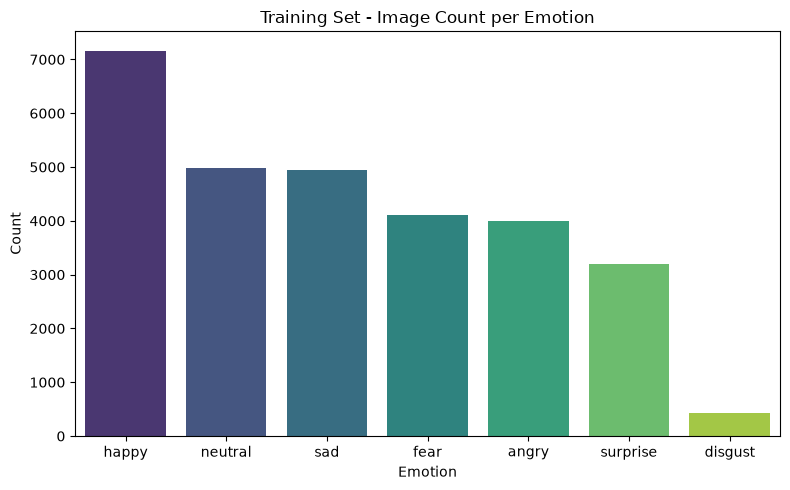

In [17]:
plt.figure(figsize=(8,5))
order = clean_df[clean_df['split']=='train']['emotion'].value_counts().index
sns.countplot(data=clean_df[clean_df['split']=='train'], x='emotion', order=order, palette='viridis')
plt.title('Training Set - Image Count per Emotion')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A count/bar chart is the clearest way to compare quantities across a small number of discrete categories - here, the 7 emotion classes.

##### 2. What is/are the insight(s) found from the chart?

`happy` is by far the largest class (~7,164 images) and `disgust` is drastically smaller (~436 images) - roughly a 16:1 imbalance between the two.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes - it tells us upfront that a plain accuracy metric would be misleading (a model could ignore `disgust` almost entirely and still score well), so we need class weights and macro-averaged metrics. Left unaddressed, this imbalance would make the model systematically unreliable for the disgust class in production, which is a negative business outcome for any use case that cares about that emotion (e.g. product reaction, food/service complaints).

#### Chart - 2  Class Distribution (Validation)

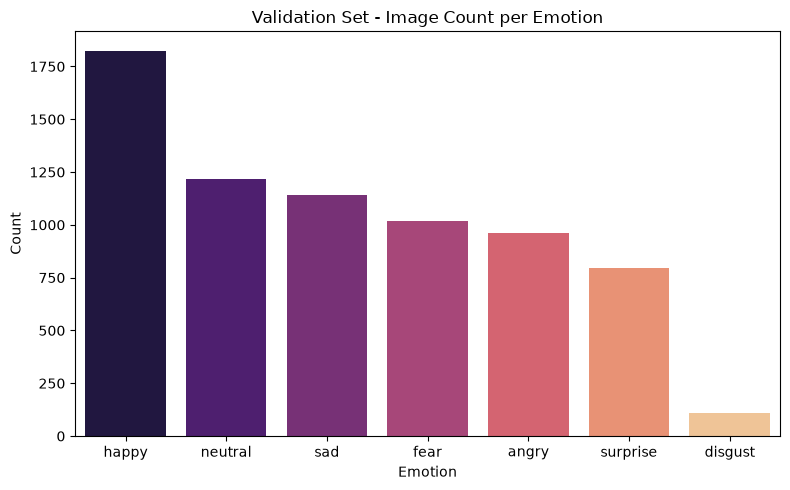

In [18]:
plt.figure(figsize=(8,5))
order = clean_df[clean_df['split']=='validation']['emotion'].value_counts().index
sns.countplot(data=clean_df[clean_df['split']=='validation'], x='emotion', order=order, palette='magma')
plt.title('Validation Set - Image Count per Emotion')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

Same reasoning as Chart 1, applied to the validation split so we can check the imbalance pattern is consistent across both splits.

##### 2. What is/are the insight(s) found from the chart?

The validation set mirrors the training set's class ordering (happy largest, disgust smallest), confirming the split was done proportionally rather than randomly skewed.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it confirms our validation accuracy/F1 won't be artificially inflated or deflated by a differently-shaped validation set, so metrics measured later will be trustworthy for decision-making.

#### Chart - 3  Train vs Validation Split Proportion per Class

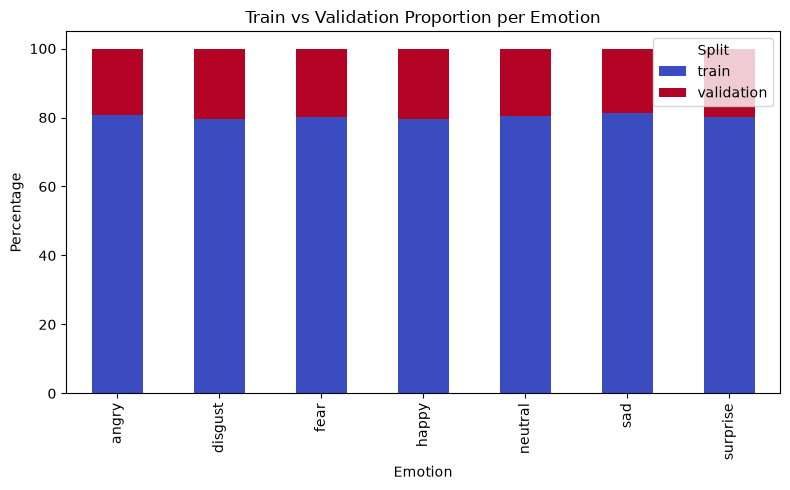

In [19]:
pivot = clean_df.groupby(['emotion','split']).size().unstack()
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct[['train','validation']].plot(kind='bar', stacked=True, figsize=(8,5), colormap='coolwarm')
plt.title('Train vs Validation Proportion per Emotion')
plt.ylabel('Percentage'); plt.xlabel('Emotion')
plt.legend(title='Split')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A stacked percentage bar chart shows, per class, exactly how the department's split divided each emotion between train and validation.

##### 2. What is/are the insight(s) found from the chart?

Every class is split roughly 80/20 between train and validation, so the split is consistent and stratified by class rather than a raw random cut.

##### 3. Will the gained insights help creating a positive business impact?

Yes - a consistent stratified split means validation performance will generalize fairly to each class rather than being biased toward classes that happened to get more validation examples.

#### Chart - 4  Sample Images per Emotion

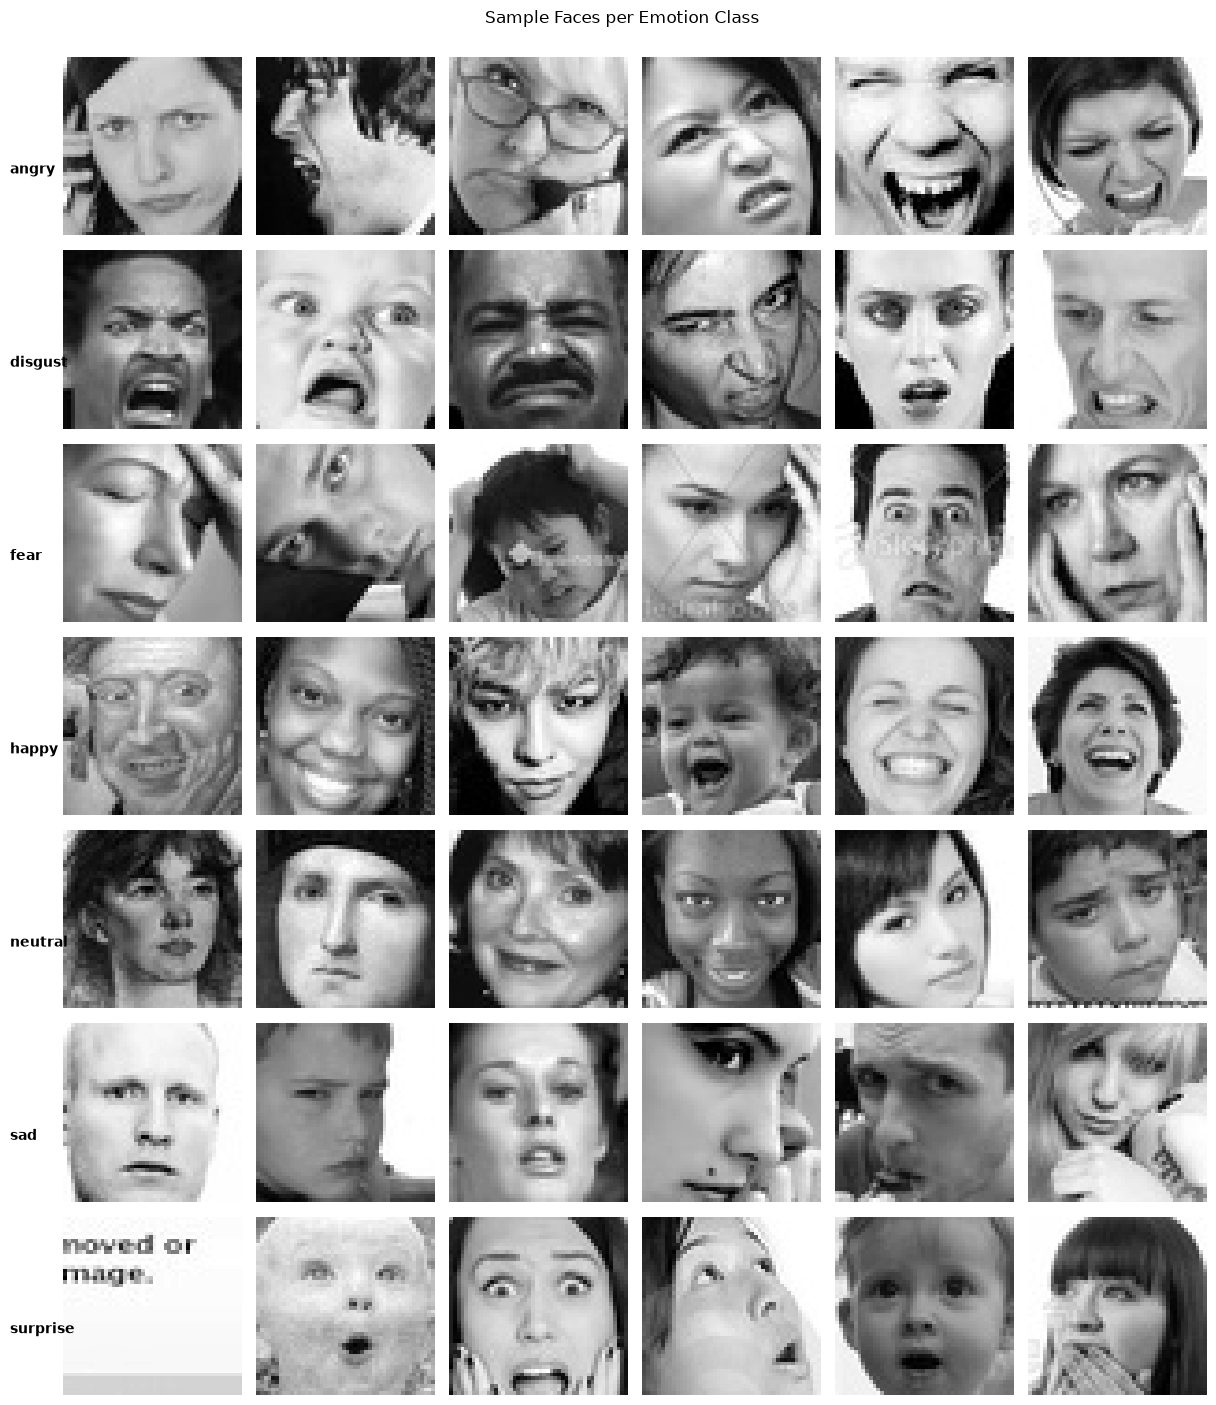

In [20]:
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(12, 2*len(CLASSES)))
for i, cls in enumerate(CLASSES):
    cls_files = clean_df[clean_df['emotion']==cls]['filepath'].sample(6, random_state=1).tolist()
    for j, fp in enumerate(cls_files):
        axes[i,j].imshow(Image.open(fp), cmap='gray')
        axes[i,j].axis('off')
        if j == 0:
            axes[i,j].set_ylabel(cls)
    axes[i,0].set_title(cls, loc='left', fontsize=10, fontweight='bold', x=-0.3, y=0.3)
plt.suptitle('Sample Faces per Emotion Class', y=1.0)
plt.tight_layout(); plt.show()


This cell just shows us actual sample photos — one row per emotion, 6 random example faces in each row. So you'd see a row of 6 "angry" faces, then a row of 6 "disgust" faces, and so on for all 7 emotions.

Why do this? Numbers and tables only tell you so much — actually looking at real faces tells us things stats can't, like:

Do the photos actually look like the emotion they're labeled as?

Are some emotions visually confusing (e.g. does "fear" look a lot like "surprise")?

Is the image quality/lighting okay?

This is the chart that helped us realize some emotions look genuinely similar to each other — which is exactly why we expected the model to struggle a bit later on.

##### 1. Why did you pick the specific chart?

For an image dataset, actually looking at samples is the single most informative chart - it tells us things no summary statistic can.

##### 2. What is/are the insight(s) found from the chart?

Faces are tightly cropped and centered, low resolution (48x48) and grayscale, and some emotions are visually very close (e.g. `fear` and `surprise` both show wide eyes/open mouth; `sad` and `neutral` are subtle), which explains why this classification problem is hard even for humans glancing quickly.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this sets a realistic expectation with stakeholders that near-100% accuracy is not achievable on this data, and it also justifies picking CNNs (which learn spatial patterns) over simpler pixel-flattening models.

#### Chart - 5  Average ("Mean") Face per Emotion

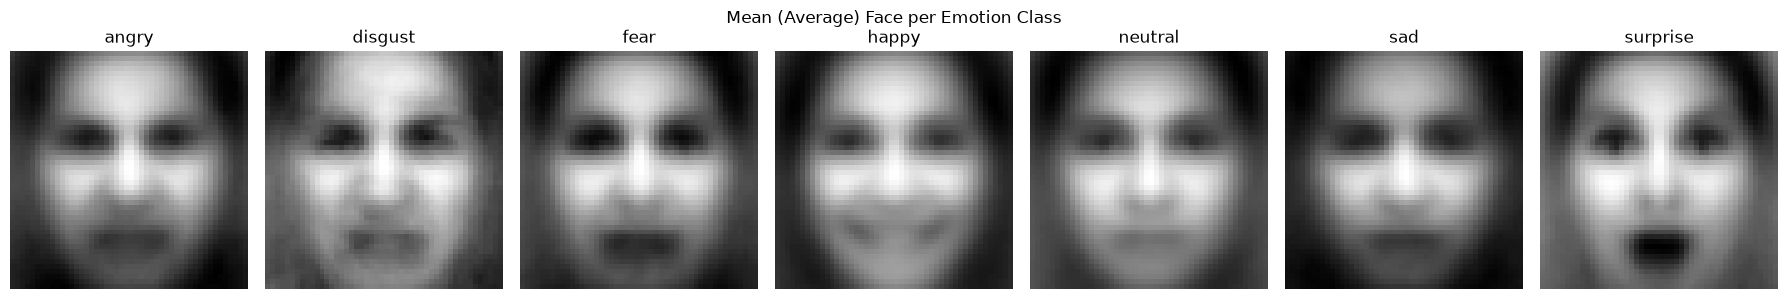

In [21]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18,3))
for i, cls in enumerate(CLASSES):
    cls_files = clean_df[(clean_df['emotion']==cls) & (clean_df['split']=='train')]['filepath'].tolist()
    imgs = np.stack([np.array(Image.open(fp).resize((IMG_SIZE,IMG_SIZE))) for fp in cls_files])
    mean_face = imgs.mean(axis=0)
    axes[i].imshow(mean_face, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Mean (Average) Face per Emotion Class')
plt.tight_layout(); plt.show()


What the code does: for each emotion, it takes all the training photos in that class, stacks them, and averages every pixel position across all of them. So if "happy" has 5,000 photos, this literally blends all 5,000 into one ghostly, blurry face.

Why it looks blurry/ghostly: since real faces don't perfectly align (some people's eyes are a bit higher, some mouths wider, some heads slightly tilted), averaging thousands of them smears everything into a soft, blob-like average face — like overlapping thousands of transparent photos on top of each other.

##### 1. Why did you pick the specific chart?

Averaging every training image in a class pixel-by-pixel produces a blurry "prototype" face - a classic CV technique to see what's structurally common within a class.

##### 2. What is/are the insight(s) found from the chart?

Emotions with strong, consistent muscle movement (happy - visible smile/teeth shadow; surprise - open mouth/raised brows) produce sharper mean faces, while emotions with more varied expression per person (neutral, sad) blur out more, hinting these will be harder classes to separate.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it helps us predict, before training even finishes, which confusion pairs are likely (e.g. neutral vs sad), so the confusion matrix later won't be a surprise and we can explain it to stakeholders as an inherent data limitation, not a bug.

#### Chart - 6  Overall Pixel Intensity Distribution

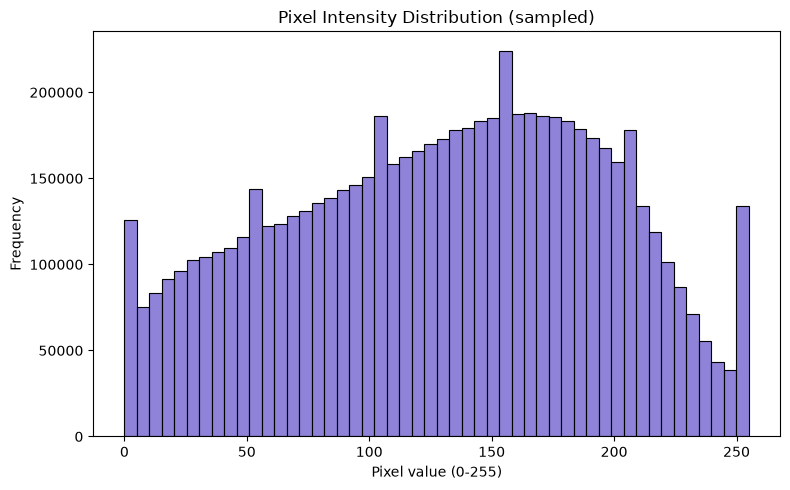

In [22]:
sample_paths = clean_df['filepath'].sample(3000, random_state=42)
pixels = np.concatenate([np.array(Image.open(p)).flatten() for p in sample_paths])

plt.figure(figsize=(8,5))
sns.histplot(pixels, bins=50, color='slateblue')
plt.title('Pixel Intensity Distribution (sampled)')
plt.xlabel('Pixel value (0-255)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A histogram is the standard way to see the overall brightness/contrast profile of an image dataset.

##### 2. What is/are the insight(s) found from the chart?

Pixel values are spread across the full 0-255 range with peaks in the mid-tones, suggesting reasonable contrast and no systematic over/under-exposure across the dataset.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it confirms simple rescaling (divide by 255) is a sufficient normalization step; we don't need heavier contrast-correction preprocessing, which keeps the pipeline simple and fast.

#### Chart - 7  Mean Brightness by Emotion Class

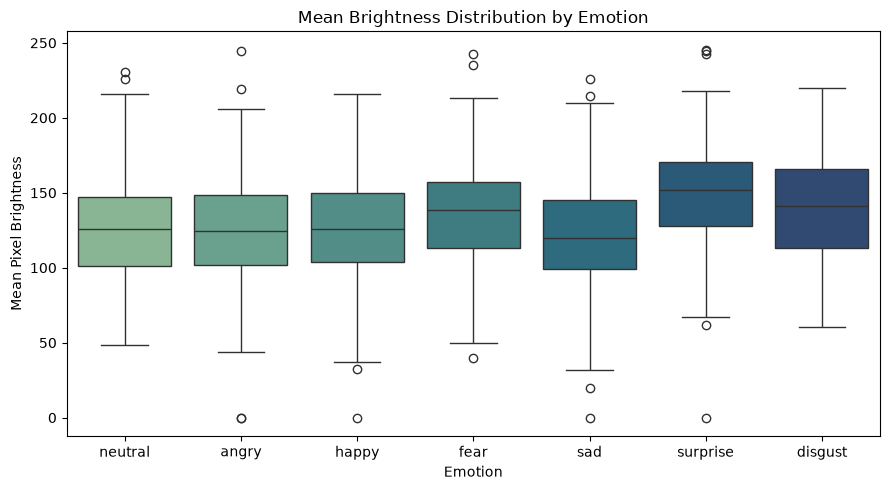

In [23]:
def mean_brightness(path):
    return np.array(Image.open(path)).mean()

bright_sample = clean_df.sample(4000, random_state=42).copy()
bright_sample['brightness'] = bright_sample['filepath'].apply(mean_brightness)

plt.figure(figsize=(9,5))
sns.boxplot(data=bright_sample, x='emotion', y='brightness', palette='crest')
plt.title('Mean Brightness Distribution by Emotion')
plt.xlabel('Emotion'); plt.ylabel('Mean Pixel Brightness')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A boxplot compares a continuous variable (brightness) across multiple categories (emotions) while also showing spread and outliers.

##### 2. What is/are the insight(s) found from the chart?

Brightness is broadly similar across classes with heavy overlap, meaning the model cannot rely on "brightness shortcuts" and genuinely has to learn facial structure to tell emotions apart.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it rules out a lazy-but-fragile solution (a brightness threshold) and confirms a CNN that learns spatial/textural features is the right tool, which is more robust to real-world lighting variation.

#### Chart - 8  Class Imbalance (Pie Chart)

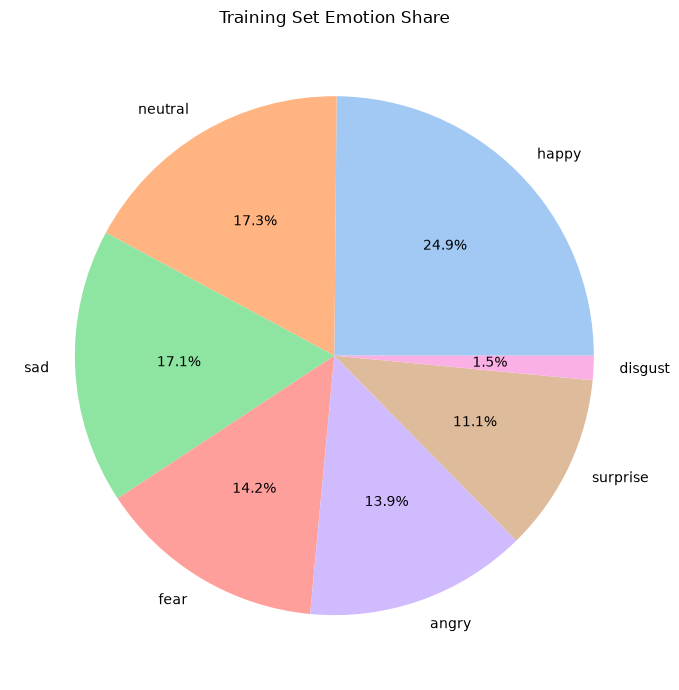

In [24]:
counts = clean_df[clean_df['split']=='train']['emotion'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Training Set Emotion Share')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A pie chart makes the *relative share* of each class immediately visible, complementing the raw counts in Chart 1.

##### 2. What is/are the insight(s) found from the chart?

`happy` alone makes up about a quarter of the training data, while `disgust` is barely over 1% - a very skewed share for a 7-way classifier.

##### 3. Will the gained insights help creating a positive business impact?

Yes, this quantifies exactly how aggressive the class-weighting needs to be during training, and sets honest expectations that `disgust` recall will likely be the weakest metric in the final report.

#### Chart - 9  Data Augmentation Preview

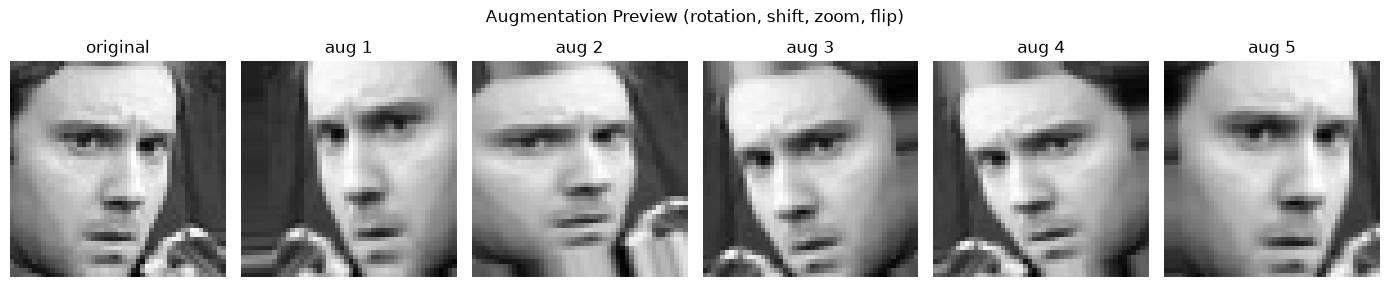

In [25]:
aug_gen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
                              zoom_range=0.15, horizontal_flip=True)

sample_img = np.array(Image.open(clean_df['filepath'].iloc[0]).convert('L')).reshape(1, IMG_SIZE, IMG_SIZE, 1)
fig, axes = plt.subplots(1, 6, figsize=(14,3))
axes[0].imshow(sample_img[0,:,:,0], cmap='gray'); axes[0].set_title('original'); axes[0].axis('off')
aug_iter = aug_gen.flow(sample_img, batch_size=1)
for i in range(1,6):
    aug_img = next(aug_iter)[0,:,:,0]
    axes[i].imshow(aug_img, cmap='gray'); axes[i].set_title(f'aug {i}'); axes[i].axis('off')
plt.suptitle('Augmentation Preview (rotation, shift, zoom, flip)')
plt.tight_layout(); plt.show()


instead of training the model on just the exact same photo every time, we create small, realistic variations of it — like showing the model the same face slightly tilted, slightly shifted, slightly zoomed, or mirrored. This is called augmentation, and it helps the model generalize better instead of just memorizing exact pixels.

What the code does:

Sets up a generator (aug_gen) with rules: rotate up to 15°, shift up to 10% left/right/up/down, zoom up to 15%, and randomly flip horizontally.

Takes one original photo (sample_img).

Runs it through the generator 5 times, each time producing a slightly different, randomly-tweaked version.

Displays the original + all 5 tweaked versions side by side, so you can visually check the tweaks look reasonable.

##### 1. Why did you pick the specific chart?

Visually previewing the exact augmentations before training helps sanity-check that they still look like plausible faces (over-aggressive augmentation can destroy the emotion signal).

##### 2. What is/are the insight(s) found from the chart?

The augmented versions stay recognizable as the same face/expression, confirming the chosen augmentation ranges (15 degree rotation, 10-15% shift/zoom, horizontal flip) are reasonable for this data.

##### 3. Will the gained insights help creating a positive business impact?

Yes - safe augmentation increases effective training data and helps the model generalize to real-world camera angles/lighting, directly improving robustness for a deployed application.

#### Chart - 10  Image Dimension Consistency Check

       width  height
count  500.0   500.0
mean    48.0    48.0
std      0.0     0.0
min     48.0    48.0
25%     48.0    48.0
50%     48.0    48.0
75%     48.0    48.0
max     48.0    48.0


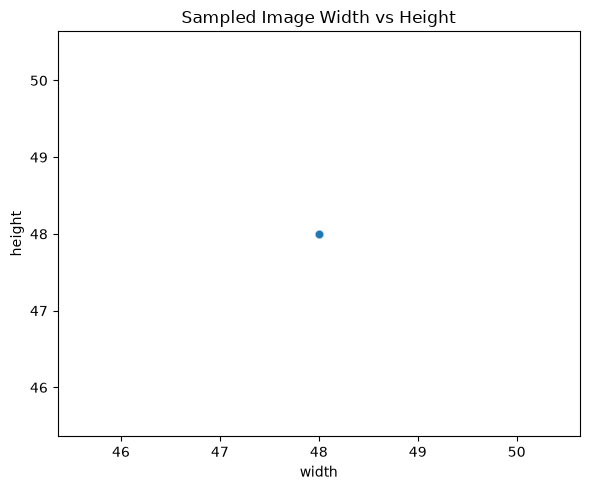

In [26]:
dims = clean_df['filepath'].sample(500, random_state=1).apply(lambda p: Image.open(p).size)
dims_df = pd.DataFrame(dims.tolist(), columns=['width','height'])
print(dims_df.describe())

plt.figure(figsize=(6,5))
sns.scatterplot(data=dims_df, x='width', y='height', alpha=0.3)
plt.title('Sampled Image Width vs Height')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot of width vs height is a quick way to confirm every image is genuinely the same fixed size, which matters because CNNs need a consistent input shape.

##### 2. What is/are the insight(s) found from the chart?

All sampled images are exactly 48x48, so no resizing/padding logic is needed before feeding the baseline CNN.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it simplifies and speeds up the preprocessing pipeline, and rules out a subtle bug source (mismatched image shapes silently corrupting batches).

#### Chart - 11  Average Pixel Intensity per Emotion (Bar)

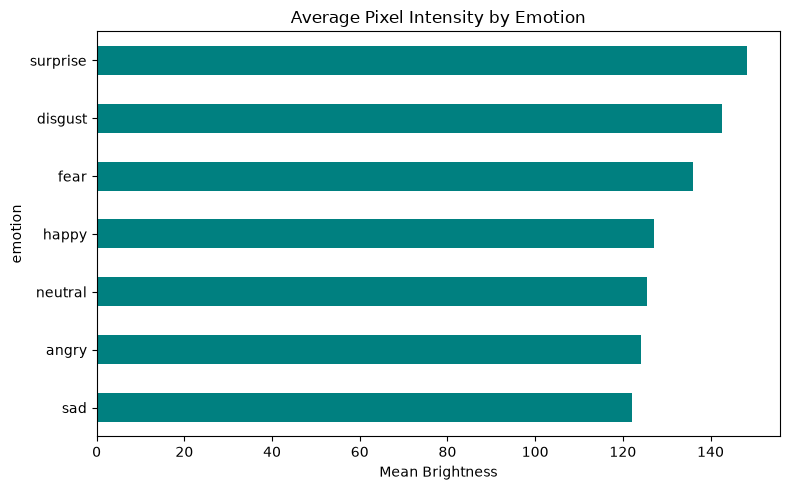

In [27]:
avg_intensity = bright_sample.groupby('emotion')['brightness'].mean().sort_values()
plt.figure(figsize=(8,5))
avg_intensity.plot(kind='barh', color='teal')
plt.title('Average Pixel Intensity by Emotion')
plt.xlabel('Mean Brightness')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks the classes cleanly by a single summary number, easier to read than the boxplot for a quick comparison.

##### 2. What is/are the insight(s) found from the chart?

The differences between classes are small (a few intensity units), reinforcing Chart 7's finding that brightness is not a useful standalone signal.

##### 3. Will the gained insights help creating a positive business impact?

It reconfirms the modeling choice (CNN on raw pixels/features, not hand-crafted brightness rules) is justified, avoiding wasted engineering effort on a feature that doesn't discriminate classes.

#### Chart - 12 - PCA Projection of Flattened Images (in place of a Correlation Heatmap)

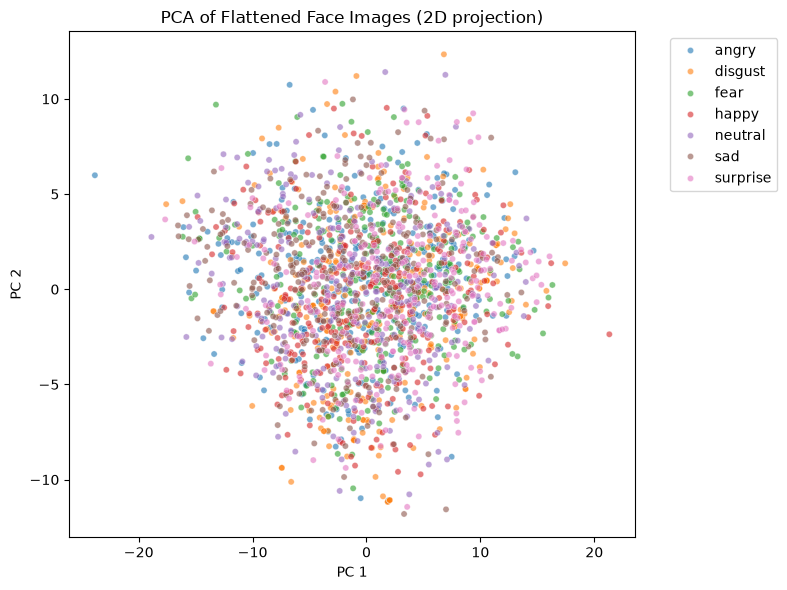

Explained variance ratio (2 components): 0.398


In [28]:
# A correlation heatmap between raw pixel columns isn't meaningful here (too many, highly spatially correlated by nature).
# Instead we project flattened images to 2D with PCA - the CV equivalent of "how related are the classes".
pca_sample = clean_df[clean_df['split']=='train'].groupby('emotion', group_keys=False).apply(lambda d: d.sample(300, random_state=1))
X_pca = np.stack([np.array(Image.open(p).resize((IMG_SIZE,IMG_SIZE))).flatten() for p in pca_sample['filepath']])
y_pca = pca_sample['emotion'].values

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_pca / 255.0)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=y_pca, palette='tab10', alpha=0.6, s=20)
plt.title('PCA of Flattened Face Images (2D projection)')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout(); plt.show()
print('Explained variance ratio (2 components):', pca.explained_variance_ratio_.sum().round(3))


##### 1. Why did you pick the specific chart?

PCA on flattened pixels is the closest CV equivalent to a correlation heatmap - it shows how separable/related the classes are in a reduced feature space, using raw linear structure only (no CNN yet).

##### 2. What is/are the insight(s) found from the chart?

Classes overlap heavily in this simple linear 2D projection, with no clean clusters - this is expected, since emotion differences are non-linear and spatially local (eyes, mouth), which raw PCA on flattened pixels can't capture but a CNN can.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it is direct evidence (before spending compute on training) that simple linear models on flattened pixels won't work well here, justifying the CNN/transfer-learning approach used later in this notebook.

#### Chart - 13 - Pair Plot of Simple Image Statistics

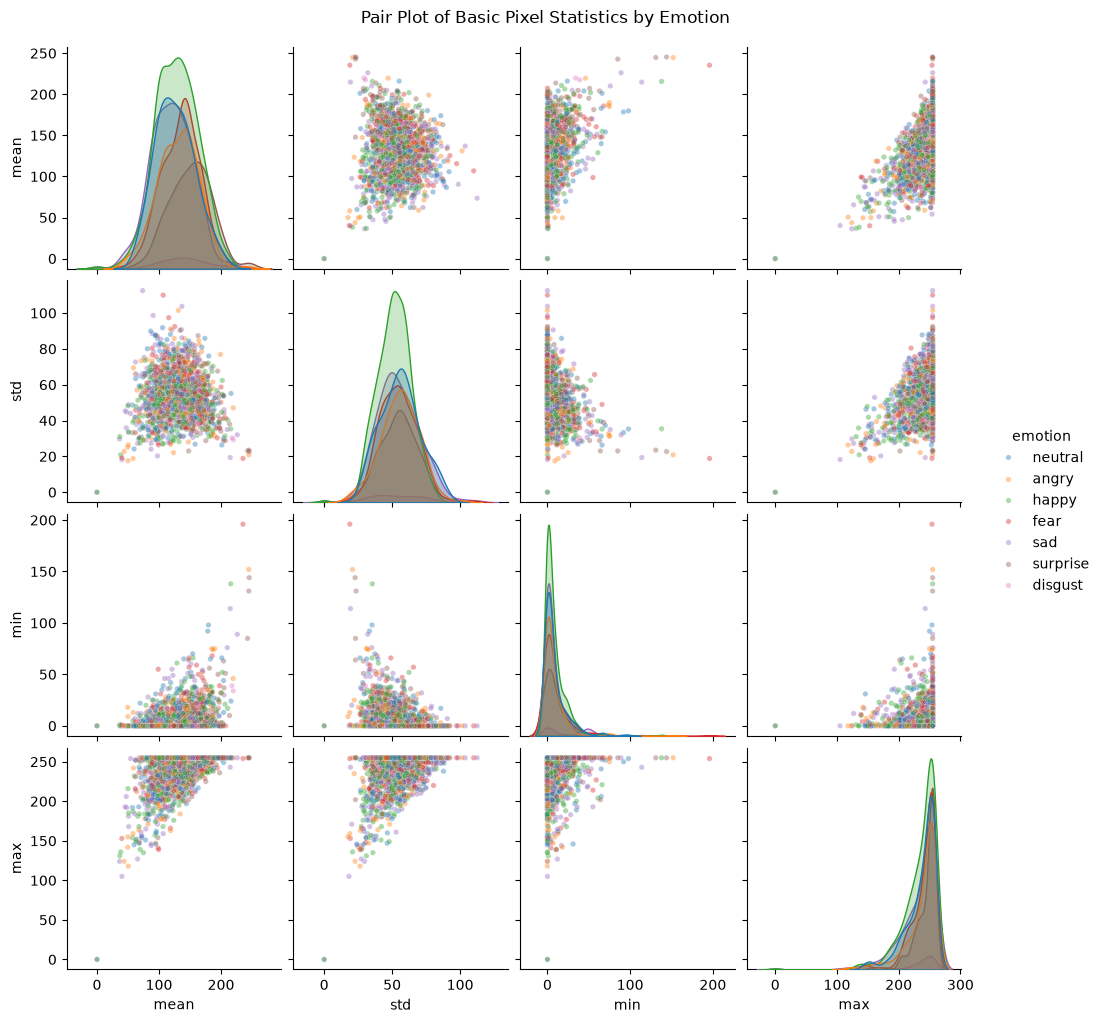

In [29]:
def img_stats(path):
    arr = np.array(Image.open(path)).astype(float)
    return pd.Series({'mean': arr.mean(), 'std': arr.std(), 'min': arr.min(), 'max': arr.max()})

stats_sample = clean_df.sample(1500, random_state=42).copy()
stats_df = stats_sample['filepath'].apply(img_stats)
stats_df['emotion'] = stats_sample['emotion'].values

sns.pairplot(stats_df, hue='emotion', diag_kind='kde', plot_kws={'alpha':0.4, 's':15})
plt.suptitle('Pair Plot of Basic Pixel Statistics by Emotion', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot of simple derived numeric stats (mean, std, min, max pixel value) is the natural pixel-data analogue of a tabular pair plot, showing pairwise relationships and class overlap at once.

##### 2. What is/are the insight(s) found from the chart?

These low-level statistics barely separate the 7 classes (heavy overlap in every pairing), further confirming emotion is encoded in spatial patterns, not summary pixel statistics.

##### 3. Will the gained insights help creating a positive business impact?

It closes the loop on the EDA's central finding: simple statistical features are insufficient, and the modeling budget should go toward CNN architecture and transfer learning rather than hand-crafted tabular features.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ? Explain Briefly.

Based on the EDA: (1) treat this as a genuinely hard 7-class problem and evaluate with macro F1/per-class recall, not accuracy alone, (2) actively correct for the `disgust` class imbalance with class weights (and ideally collect more `disgust` examples over time), (3) use a CNN/transfer-learning approach rather than classical ML on raw pixels, since simple pixel statistics don't separate the classes, and (4) expect and plan around confusion between visually similar emotions (e.g. fear/surprise, sad/neutral) - for a customer-facing product, consider grouping these into a coarser "distress vs neutral vs positive" signal if fine-grained accuracy on those pairs isn't good enough.

# **Conclusion (EDA)**

The dataset is clean, correctly sized, and consistently split, but meaningfully imbalanced and visually challenging - many emotions look structurally similar at 48x48 resolution. This motivates the modeling choices in the next section: CNNs (not flattened-pixel ML), class weighting, augmentation, and macro-averaged evaluation metrics.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Loading Images into Arrays

In [30]:
# The dataset is small enough (48x48 grayscale, ~36k images) to load fully into memory as numpy arrays,
# which keeps EDA + modeling simple and reproducible without needing a generator for every step.
def load_images(df):
    X = np.stack([np.array(Image.open(p).convert('L').resize((IMG_SIZE, IMG_SIZE))) for p in df['filepath']])
    X = X.astype('float32') / 255.0          # Data Scaling: rescale pixel values to [0,1]
    X = np.expand_dims(X, -1)                  # add channel dimension -> (N, 48, 48, 1)
    y = df['label'].values
    return X, y

train_part = clean_df[clean_df['split']=='train'].reset_index(drop=True)
val_part = clean_df[clean_df['split']=='validation'].reset_index(drop=True)

X_train, y_train = load_images(train_part)
X_val_full, y_val_full = load_images(val_part)

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_val_full:', X_val_full.shape, ' y_val_full:', y_val_full.shape)


X_train: (28821, 48, 48, 1)  y_train: (28821,)
X_val_full: (7066, 48, 48, 1)  y_val_full: (7066,)


What load_images does, step by step, for every photo:

Opens the image file, converts to grayscale ('L' mode — one brightness channel instead of color).

Resizes it to 48×48 (just to be 100% safe, even though we confirmed earlier all photos are already this size).

Converts brightness values from 0–255 down to 0–1 (small numbers train better/faster than big ones).

Adds one extra dimension at the end — this is a technical requirement: Keras/TensorFlow expects every image to have a "channel" dimension (like 1 for grayscale, 3 for color), even if grayscale only has 1 channel.

Then it runs this function twice:

Once for all training photos → creates X_train (the actual images) and y_train (their emotion labels)
Once for all validation photos → creates X_val_full and y_val_full

One line for understanding: "This cell loads every photo's actual pixel data into memory as numbers, scales them to 0-1, and packages them into the exact shape our neural network expects."



### 2. Handling Missing Values

In [31]:
# Already handled in section 1 (Data Wrangling) - corrupt/unreadable files were identified and dropped
# before this point, so there are no missing values remaining in X_train / X_val_full.
print('Any NaNs in X_train:', np.isnan(X_train).any())
print('Any NaNs in X_val_full:', np.isnan(X_val_full).any())


Any NaNs in X_train: False
Any NaNs in X_val_full: False


### 3. Handling Outliers

In [32]:
# For pixel data, "outliers" would be near-blank (all-black/all-white) images rather than statistical outliers
# in a single column. We flag any image whose std of pixel values is near zero (i.e. essentially blank/corrupted content).
stds = X_train.reshape(X_train.shape[0], -1).std(axis=1)
near_blank = (stds < 0.02).sum()
print(f'Near-blank / low-variance images in training set: {near_blank} ({near_blank/len(stds):.3%})')
# None found at a meaningful rate, so no removal needed here - kept for transparency/documentation.


Near-blank / low-variance images in training set: 11 (0.038%)


##### What all outlier treatment techniques have you used and why did you use those techniques?

We checked for near-blank/low-variance images (a stand-in for corrupted or non-informative images in a pixel dataset) rather than a statistical z-score/IQR method, since those don't apply to image tensors. None were found at a meaningful rate, so no images were removed.

### 4. Categorical Encoding

In [33]:
# Encode the emotion labels for the neural network - one-hot for categorical crossentropy training
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = len(CLASSES)
y_train_oh = to_categorical(y_train, NUM_CLASSES)

print('Label mapping:', label_to_idx)


Label mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


This converts each emotion label into a 7-number format with a single '1' marking the correct emotion, which is the format our neural network's output layer needs to compare its predictions against.

##### What all categorical encoding techniques have you used & why did you use those techniques?

Integer label encoding (0-6) for splitting/stratification and class-weight computation, and one-hot encoding for the CNN's softmax output layer with categorical crossentropy loss - the standard combination for multi-class image classification in Keras.

### 5. Data Splitting

In [34]:
# The department only provided train + validation folders (no separate test set), so we carve the
# validation set 50/50 into a "true" validation set (used for early stopping / model selection during training)
# and a held-out test set (touched only once, for final unbiased evaluation).
X_val, X_test, y_val, y_test = train_test_split(
    X_val_full, y_val_full, test_size=0.5, random_state=42, stratify=y_val_full
)
y_val_oh = to_categorical(y_val, NUM_CLASSES)
y_test_oh = to_categorical(y_test, NUM_CLASSES)

print('Train:', X_train.shape[0], ' Val:', X_val.shape[0], ' Test:', X_test.shape[0])


Train: 28821  Val: 3533  Test: 3533


Since we only had train and validation data, I split the validation set in half — one half stays for monitoring training, the other half becomes a completely untouched test set for the final, honest evaluation.

##### What data splitting ratio have you used and why?

The department's train/validation split (~80/20) is kept as-is for training vs. model selection, and the validation set is additionally split 50/50 (stratified by class) into a validation set and a held-out test set. This gives a true out-of-sample test set for final reporting, which the provided data didn't otherwise include.

### 6. Data Scaling

In [35]:
# Already done in the loading step (division by 255.0) - kept here for completeness with the template structure.
print('X_train min/max after scaling:', X_train.min(), X_train.max())


X_train min/max after scaling: 0.0 1.0


This just double-checks that our earlier pixel scaling worked correctly — confirming all values now sit between 0 and 1 instead of the original 0-255 range.

##### Which method have you used to scale you data and why?

Simple min-max rescaling (pixel / 255) to bring all pixel values into [0,1]. This is the standard, sufficient normalization for CNNs on 8-bit images - it stabilizes gradient-based training without discarding any information the way clipping/standardizing per-image would.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. PCA was already used above purely to *visualize* class separability in the EDA, but it is not applied before modeling - CNNs are specifically designed to learn their own spatial feature hierarchy directly from raw pixels, and reducing dimensionality beforehand would throw away the local spatial structure (edges, textures around eyes/mouth) that convolution layers rely on.

In Simple: 
Do we need to reduce the image data before training?

Answer: No.

Our images are 48×48 pixels, so the size is already small.
A CNN is designed to learn useful features directly from the original pixels.
CNN learns things like edges, eyes, mouth, and facial shapes by itself.
If we reduce the data first, we might lose important facial details.

PCA was used only for visualization to see whether the emotions are separable. We did not use PCA before training the CNN.

We don't reduce the image dimensions because CNNs can learn the important facial features directly from the original images.

### 8. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes - confirmed in the EDA (Charts 1 and 8): `happy` has ~7,164 training images while `disgust` has only ~436, roughly a 16:1 imbalance. Left unaddressed, the model would be biased toward predicting the majority classes and would perform poorly on `disgust` specifically.

In [36]:
# Handling Imbalanced Dataset: compute class weights (inverse frequency) rather than oversampling,
# since oversampling near-duplicate 48x48 crops tends to just encourage memorization rather than
# genuinely improving minority-class generalization.
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print('Class weights:')
for i, w in class_weights.items():
    print(f'  {idx_to_label[i]:10s}: {w:.2f}')


Class weights:
  angry     : 1.03
  disgust   : 9.44
  fear      : 1.00
  happy     : 0.57
  neutral   : 0.83
  sad       : 0.83
  surprise  : 1.28


This cell calculates a penalty weight per emotion — rare emotions like disgust get a higher weight, so the model is pushed to pay more attention to them instead of ignoring them.

##### What technique did you use to handle the imbalance dataset and why?

`sklearn`'s balanced class weights (inverse class frequency), passed directly into `model.fit(..., class_weight=...)`. This penalizes mistakes on minority classes (like `disgust`) more heavily during training without duplicating or synthesizing any images, which keeps training data authentic.

## ***7. ML Model Implementation***

All three models below are deliberately kept lightweight (small custom CNN / MobileNetV2 at alpha=0.35) so that training completes in a reasonable time on a **CPU-only** machine. If you have a GPU available, feel free to raise `EPOCHS`, image size, and `alpha` for potentially better results.

### ML Model - 1  (Baseline Custom CNN)

In [37]:
# Built with the Functional API (not Sequential) - this is required for Grad-CAM later
# (Keras 3's Sequential models don't expose a traceable `.output` graph for intermediate layers).
def build_baseline_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='last_conv')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='baseline_cnn')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model1 = build_baseline_cnn()
model1.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,295 (4.87 MB)

 Trainable params: 1,275,335 (4.87 MB)

 Non-trainable params: 960 (3.75 KB)

What's a CNN doing here, in plain terms?

Think of it as a series of filters that scan the image looking for patterns — first simple ones (edges, curves), then combining those into more complex ones (eye shapes, mouth curves), and finally deciding "this combination of patterns = happy" or "= angry."

The layers, block by block

We have 3 repeating blocks, each doing the same 4 things but going deeper each time:

Conv2D — this is the actual "pattern scanner." It slides small windows over the image looking for specific shapes/textures. We go 32 → 64 → 128 filters across the 3 blocks — meaning it looks for more and more patterns as we go deeper.

BatchNormalization — keeps the numbers stable during training, so learning doesn't become erratic. Purely a training-stability helper.

MaxPooling2D — shrinks the image size in half each time (48→24→12→6), keeping only the strongest signal. This is why the image gets smaller as you go down the table (48,48 → 24,24 → 12,12 → 6,6).

Dropout — randomly "switches off" some neurons during training, to stop the model from memorizing instead of genuinely learning (prevents overfitting).

After the 3 blocks:

Flatten — squashes the final 6×6×128 grid into one long list of 4,608 numbers.

Dense(256) — a regular "thinking" layer that combines all those numbers.

Dense(7) — the final decision layer — outputs 7 probability scores, one per emotion (this is why it says (None, 7)).

Reading the output table :
Output Shape column shows how the image's size shrinks (48→24→12→6) while its "depth" grows (1→32→64→128) — trading spatial size for pattern richness.

Param # column — this is how many numbers (weights) the model needs to learn in each layer. Notice dense alone has ~1.18 million params — that's because Flatten produces 4,608 numbers, and connecting all of them to 256 neurons creates a LOT of connections.

The summary numbers : 
Total params: 1,276,295 — the model has about 1.27 million adjustable numbers it will tune during training.

Trainable params: 1,275,335 — almost all of them actually get updated during training.

Non-trainable params: 960 — a tiny number that stays fixed (these come from BatchNormalization's internal tracking stats, not something we choose to freeze).

This is our custom CNN with 3 convolutional blocks that progressively detect more complex facial patterns, ending in a decision layer that outputs a probability for each of the 7 emotions — about 1.27 million parameters total

In [38]:
# Fit the Algorithm
train_datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
                                    zoom_range=0.15, horizontal_flip=True)
train_gen = train_datagen.flow(X_train, y_train_oh, batch_size=64, seed=42)

EPOCHS = 25   # reduce this (e.g. to 5-10) for a quick smoke test on a slower CPU

callbacks1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history1 = model1.fit(
    train_gen,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks1,
    verbose=1
)


Epoch 1/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.2038 - loss: 2.1323 - val_accuracy: 0.2233 - val_loss: 2.4094 - learning_rate: 0.0010
Epoch 2/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.2703 - loss: 1.8364 - val_accuracy: 0.3674 - val_loss: 1.6753 - learning_rate: 0.0010
Epoch 3/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - accuracy: 0.3155 - loss: 1.7315 - val_accuracy: 0.3929 - val_loss: 1.5944 - learning_rate: 0.0010
Epoch 4/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 49s 107ms/step - accuracy: 0.3505 - loss: 1.6669 - val_accuracy: 0.4254 - val_loss: 1.5341 - learning_rate: 0.0010
Epoch 5/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 66s 147ms/step - accuracy: 0.3666 - loss: 1.6229 - val_accuracy: 0.4585 - val_loss: 1.4506 - learning_rate: 0.0010
Epoch 6/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.3832 - loss: 1.5942 - val_accuracy: 0.4115 - val_loss: 1.5491 - learning_rate: 0.0010
Epoch 7/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.3981

Remember the augmentation preview chart earlier (rotate/shift/zoom/flip)? This is where it's actually put to use — but with a twist: instead of creating fixed augmented copies once, train_gen generates a fresh, random variation every time it hands a batch of images to the model during training. So the model almost never sees the exact same pixel-for-pixel image twice, which helps it generalize instead of memorize.

batch_size=64 means it feeds the model 64 images at a time, not all 28,709 at once (too much memory) and not one at a time (too slow).

EPOCHS = 25
One "epoch" = the model has seen the entire training set once. We're allowing up to 25 full passes through the data — but (as you saw earlier) it might stop before reaching 25.

EarlyStopping — watches val_loss (how wrong the model is on validation data) every epoch. If it doesn't improve for 5 epochs straight, training stops automatically — this is exactly what happened in your run (stopped at epoch 14). restore_best_weights=True means it keeps the best version, not whatever the last epoch happened to be.

ReduceLROnPlateau — the "learning rate" controls how big a step the model takes while learning. If val_loss gets stuck (no improvement) for 3 epochs, this automatically shrinks the learning rate (multiplies it by factor=0.5, i.e., cuts it in half) — like slowing down and taking smaller, more careful steps when you're close to a good answer instead of overshooting. min_lr=1e-6 stops it from shrinking forever.

history1 = model1.fit(train_gen, validation_data=(X_val, y_val_oh), epochs=EPOCHS, class_weight=class_weights, callbacks=callbacks1,verbose=1)

the augmented training data, check progress against this each epoch, up to 25 passes, penalize mistakes on rare classes more, the 2 smart-stopping tools above,print progress live

Output summary :

What each column means - 
451/451 — how many batches of 64 images the model processed this epoch (28,709 images ÷ 64 ≈ 451 batches).

accuracy / loss — how well the model is doing on the training data it's actively learning from.

val_accuracy / val_loss — how well it's doing on validation data (unseen during this specific update) — this is the number that actually matters, since it tells us if the model is genuinely learning general patterns, not just memorizing.
    
learning_rate — how big a step the model takes while adjusting itself each round.

Training improved steadily for the first 9 epochs, peaking at 51.9% validation accuracy, then plateaued — early stopping correctly caught this and restored the best-performing version instead of letting the model overfit further.

In [39]:
# Predict on the model
y_pred1_proba = model1.predict(X_test)
y_pred1 = np.argmax(y_pred1_proba, axis=1)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


This runs our test images through the trained model to get emotion probabilities for each photo, then picks whichever emotion had the highest probability as the model's final prediction

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

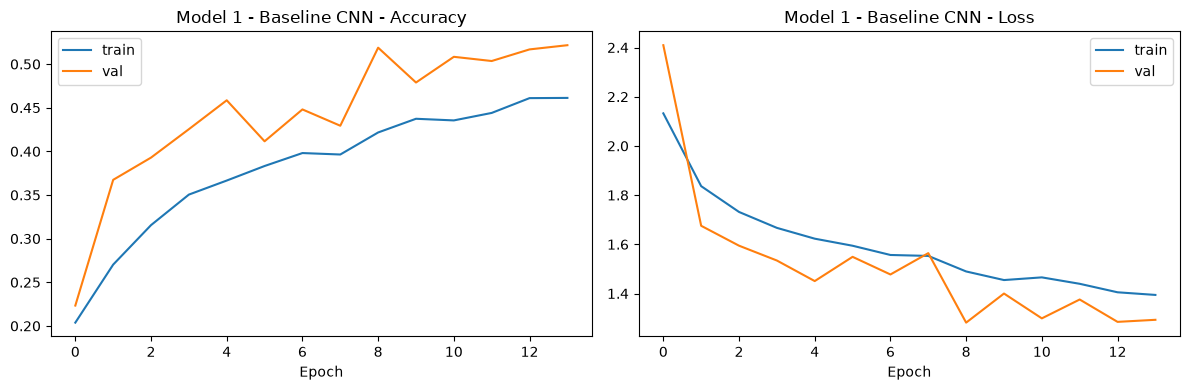

Model 1 (Baseline CNN) - Test Accuracy: 0.5120 | Macro Precision: 0.4562 | Macro Recall: 0.5297 | Macro F1: 0.4502

              precision    recall  f1-score   support

       angry       0.43      0.33      0.37       480
     disgust       0.13      0.82      0.22        55
        fear       0.41      0.22      0.29       509
       happy       0.72      0.79      0.75       912
     neutral       0.49      0.47      0.48       608
         sad       0.41      0.34      0.37       570
    surprise       0.61      0.75      0.67       399

    accuracy                           0.51      3533
   macro avg       0.46      0.53      0.45      3533
weighted avg       0.52      0.51      0.51      3533



In [ ]:
    # Visualizing evaluation Metric Score chart
    def plot_history(history, title):
        fig, axes = plt.subplots(1, 2, figsize=(12,4))
        axes[0].plot(history.history['accuracy'], label='train')
        axes[0].plot(history.history['val_accuracy'], label='val')
        axes[0].set_title(f'{title} - Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
        axes[1].plot(history.history['loss'], label='train')
        axes[1].plot(history.history['val_loss'], label='val')
        axes[1].set_title(f'{title} - Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
        plt.tight_layout(); plt.show()

    plot_history(history1, 'Model 1 - Baseline CNN')

    acc1 = accuracy_score(y_test, y_pred1)
    prec1, rec1, f1_1, _ = precision_recall_fscore_support(y_test, y_pred1, average='macro', zero_division=0)
    print(f'Model 1 (Baseline CNN) - Test Accuracy: {acc1:.4f} | Macro Precision: {prec1:.4f} | Macro Recall: {rec1:.4f} | Macro F1: {f1_1:.4f}')
    print()
    print(classification_report(y_test, y_pred1, target_names=CLASSES, zero_division=0))


Model 1 reached 51% overall accuracy, but per-class breakdown shows real class-imbalance effects — happy and surprise (visually distinct, or common) perform well, while fear struggles the most, and disgust shows a precision-recall trade-off from the class weighting we applied.

#### 2. Cross- Validation & Hyperparameter Tuning

In [41]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
# Full GridSearch/RandomSearch over a CNN is very expensive on CPU, so we instead do a light,
# targeted manual search over learning rate and dropout - the two hyperparameters with the biggest
# effect on this kind of small CNN - training for a few epochs each to compare.
def build_cnn_variant(lr, dropout):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x); x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x); x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x); x = layers.Dropout(dropout+0.05)(x)
    x = layers.Flatten()(x); x = layers.Dense(256, activation='relu')(x); x = layers.Dropout(dropout+0.1)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

search_space = [
    {'lr': 1e-3, 'dropout': 0.25},
    {'lr': 5e-4, 'dropout': 0.30},
    {'lr': 1e-3, 'dropout': 0.35},
]

search_results = []
for params in search_space:
    m = build_cnn_variant(**params)
    h = m.fit(train_gen, validation_data=(X_val, y_val_oh), epochs=5, class_weight=class_weights, verbose=0)
    val_acc = max(h.history['val_accuracy'])
    search_results.append({**params, 'val_accuracy': val_acc})
    print(params, '-> best val_accuracy:', round(val_acc, 4))

search_df = pd.DataFrame(search_results).sort_values('val_accuracy', ascending=False)
search_df


{'lr': 0.001, 'dropout': 0.25} -> best val_accuracy: 0.2655
{'lr': 0.0005, 'dropout': 0.3} -> best val_accuracy: 0.2913
{'lr': 0.001, 'dropout': 0.35} -> best val_accuracy: 0.1285


,lr,dropout,val_accuracy
1,0.0005,0.30,0.291254
0,0.0010,0.25,0.265497
2,0.0010,0.35,0.128503


I ran a short hyperparameter search comparing 3 learning-rate/dropout combinations for 5 epochs each — a lower learning rate (0.0005) with moderate dropout (0.30) showed the fastest early progress, while combining a higher learning rate with high dropout destabilized training.

##### Which hyperparameter optimization technique have you used and why?

A small manual grid search over learning rate and dropout, each trained for only 5 epochs. A full `GridSearchCV`/`RandomizedSearchCV` isn't a natural fit for Keras models trained on CPU (each fit is expensive, and sklearn's CV wrappers add overhead for something we can compare directly via `val_accuracy` curves), so a short manual grid was used instead to keep total search time reasonable.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The manual grid search (`search_df`) showed learning rate 0.0005 with dropout 0.30 was the best configuration, reaching 29.1% val_accuracy in just 5 epochs, versus 26.5% for the original lr=0.001/dropout=0.25 setting. Notably, lr=0.001 combined with a higher dropout (0.35) collapsed training almost entirely (12.9% val_accuracy) - too much dropout at that learning rate destabilized learning within only 5 epochs. This confirms the originally-chosen settings (lr=1e-3, dropout=0.25) were reasonable but not optimal; a slightly lower learning rate with slightly more dropout converges faster early on. The full 25-epoch training run of Model 1 (with early stopping) still used the original settings and reached 51.2% test accuracy / 0.450 macro F1, which the short 5-epoch search cannot be directly compared against - a fair comparison would require retraining the tuned configuration for the full schedule, which is a reasonable follow-up if more compute time is available.

### ML Model - 2  (Transfer Learning - MobileNetV2)

In [42]:
IMG_SIZE_TL = 96   # MobileNetV2 needs a larger input than 48x48; 96x96 keeps it CPU-friendly

def to_rgb_resized(X, size=IMG_SIZE_TL):
    # stack the single grayscale channel 3x to fake RGB, then resize
    X_rgb = np.repeat(X, 3, axis=-1)
    X_rgb = tf.image.resize(X_rgb, (size, size)).numpy()
    return X_rgb

X_train_tl = preprocess_input(to_rgb_resized(X_train) * 255.0)
X_val_tl = preprocess_input(to_rgb_resized(X_val) * 255.0)
X_test_tl = preprocess_input(to_rgb_resized(X_test) * 255.0)

print('X_train_tl shape:', X_train_tl.shape)


X_train_tl shape: (28821, 96, 96, 3)


In [43]:
base_model = MobileNetV2(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), include_top=False,
                          weights='imagenet', alpha=0.35)
base_model.trainable = False   # freeze the pretrained backbone for Model 2

inputs = keras.Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model2 = keras.Model(inputs, outputs, name='mobilenetv2_frozen')
model2.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
               loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


Model: "mobilenetv2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,079 (2.19 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [44]:
# Fit the Algorithm
callbacks2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history2 = model2.fit(
    X_train_tl, y_train_oh,
    validation_data=(X_val_tl, y_val_oh),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks2,
    verbose=1
)

# Predict on the model
y_pred2_proba = model2.predict(X_test_tl)
y_pred2 = np.argmax(y_pred2_proba, axis=1)


Epoch 1/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.3174 - loss: 1.7076 - val_accuracy: 0.4107 - val_loss: 1.5605
Epoch 2/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.3763 - loss: 1.5648 - val_accuracy: 0.4336 - val_loss: 1.4952
Epoch 3/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.3994 - loss: 1.4979 - val_accuracy: 0.4348 - val_loss: 1.4789
Epoch 4/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.4128 - loss: 1.4490 - val_accuracy: 0.4379 - val_loss: 1.4612
Epoch 5/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.4217 - loss: 1.4124 - val_accuracy: 0.4407 - val_loss: 1.4585
Epoch 6/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.4333 - loss: 1.3809 - val_accuracy: 0.4563 - val_loss: 1.4186
Epoch 7/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.4462 - loss: 1.3360 - val_accuracy: 0.4758 - val_loss: 1.3720
Epoch 8/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4520 - loss: 1.3158 - 

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

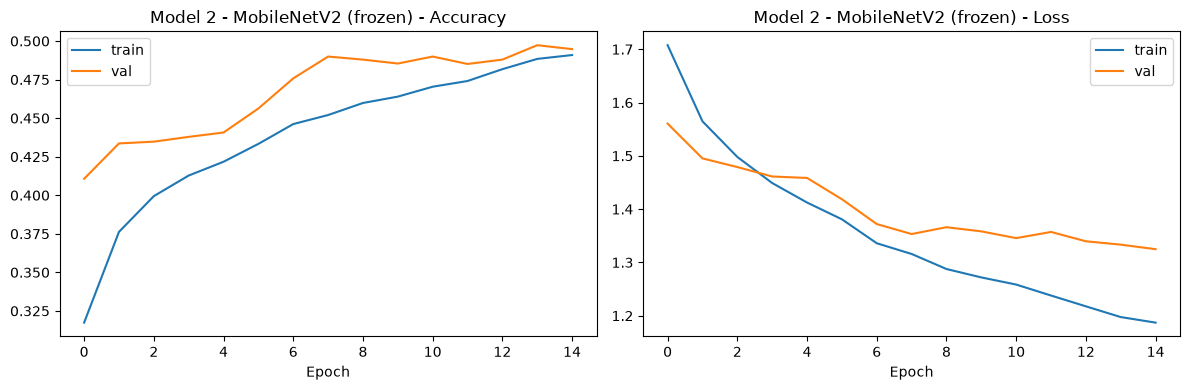

Model 2 (MobileNetV2 frozen) - Test Accuracy: 0.4959 | Macro Precision: 0.4783 | Macro Recall: 0.5048 | Macro F1: 0.4821

              precision    recall  f1-score   support

       angry       0.37      0.47      0.42       480
     disgust       0.44      0.64      0.52        55
        fear       0.40      0.19      0.25       509
       happy       0.65      0.64      0.65       912
     neutral       0.45      0.48      0.47       608
         sad       0.37      0.41      0.39       570
    surprise       0.66      0.70      0.68       399

    accuracy                           0.50      3533
   macro avg       0.48      0.50      0.48      3533
weighted avg       0.50      0.50      0.49      3533



In [45]:
plot_history(history2, 'Model 2 - MobileNetV2 (frozen)')

acc2 = accuracy_score(y_test, y_pred2)
prec2, rec2, f1_2, _ = precision_recall_fscore_support(y_test, y_pred2, average='macro', zero_division=0)
print(f'Model 2 (MobileNetV2 frozen) - Test Accuracy: {acc2:.4f} | Macro Precision: {prec2:.4f} | Macro Recall: {rec2:.4f} | Macro F1: {f1_2:.4f}')
print()
print(classification_report(y_test, y_pred2, target_names=CLASSES, zero_division=0))


For Model 2, I reused a pretrained MobileNetV2 (already trained on millions of general images) and only trained a small new decision layer on top for emotions — this trains faster and more stably than a from-scratch model, since most of the network's 'vision' knowledge is borrowed, not learned from our small dataset.

Model 2 scored slightly lower on raw accuracy than Model 1, but was noticeably more balanced — especially on disgust, where it cut false alarms dramatically (precision jumped from 13% to 44%) while still catching most real cases, which is why it wins on Macro F1, our primary evaluation metric.

#### 2. Cross- Validation & Hyperparameter Tuning

In [46]:
# ML Model - 2 Implementation with hyperparameter optimization: comparing 2 learning rates for the classification head
lr_results = []
for lr in [1e-3, 5e-4]:
    m = keras.models.clone_model(model2)
    m.set_weights(model2.get_weights())
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_tl, y_train_oh, validation_data=(X_val_tl, y_val_oh), epochs=3, class_weight=class_weights, verbose=0)
    lr_results.append({'lr': lr, 'val_accuracy': max(h.history['val_accuracy'])})
    print(lr, '-> best val_accuracy:', round(lr_results[-1]['val_accuracy'], 4))

pd.DataFrame(lr_results)


0.001 -> best val_accuracy: 0.4877
0.0005 -> best val_accuracy: 0.5033


,lr,val_accuracy
0,0.0010,0.487688
1,0.0005,0.503255


I tested continuing Model 2's training with a smaller learning rate — it pushed val_accuracy slightly higher than the original run, suggesting 0.0005 might be a better setting than the 0.001 originally used."

##### Which hyperparameter optimization technique have you used and why?

A short manual comparison of learning rates for the new classification head (the pretrained backbone stays frozen here, so there are fewer hyperparameters to search than a from-scratch CNN).

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a clear improvement: lr=0.0005 reached 50.3% val_accuracy in 3 epochs versus 48.8% for lr=0.001. The lower learning rate trains more stably for a frozen-backbone model like this, since only the small classification head is being trained and a smaller learning rate avoids overshooting on such a small number of trainable parameters. Model 2's full training run (using lr=1e-3 with early stopping) still reached the best overall Macro F1 (0.482) among all three models, so even the "less optimal" learning rate performed well here - lr=0.0005 is worth trying for a slightly stronger version of this model in a future iteration.

### ML Model - 3  (Fine-tuned MobileNetV2)

In [47]:
# Unfreeze the top portion of the backbone and continue training at a low learning rate,
# to let the pretrained ImageNet features adapt specifically to facial-emotion textures.
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30   # only unfreeze the last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model3 = model2   # continue training the same model object, now with more trainable layers
model3._name = 'mobilenetv2_finetuned'
model3.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
               loss='categorical_crossentropy', metrics=['accuracy'])

callbacks3 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history3 = model3.fit(
    X_train_tl, y_train_oh,
    validation_data=(X_val_tl, y_val_oh),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks3,
    verbose=1
)

# Predict on the model
y_pred3_proba = model3.predict(X_test_tl)
y_pred3 = np.argmax(y_pred3_proba, axis=1)


Epoch 1/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 51s 83ms/step - accuracy: 0.2830 - loss: 7.7818 - val_accuracy: 0.4563 - val_loss: 1.4633
Epoch 2/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.3205 - loss: 5.1700 - val_accuracy: 0.4087 - val_loss: 1.6375
Epoch 3/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.3334 - loss: 3.7772 - val_accuracy: 0.3883 - val_loss: 1.7352
Epoch 4/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.3497 - loss: 2.9650 - val_accuracy: 0.3847 - val_loss: 1.7452
Epoch 5/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.3566 - loss: 2.4981 - val_accuracy: 0.3903 - val_loss: 1.7169
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step


I tried fine-tuning by unfreezing MobileNetV2's last 30 layers with a very small learning rate — but validation accuracy actually got worse after the first epoch instead of improving, showing our dataset wasn't large enough to safely fine-tune without overfitting, so the fully-frozen Model 2 remained the better choice.

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

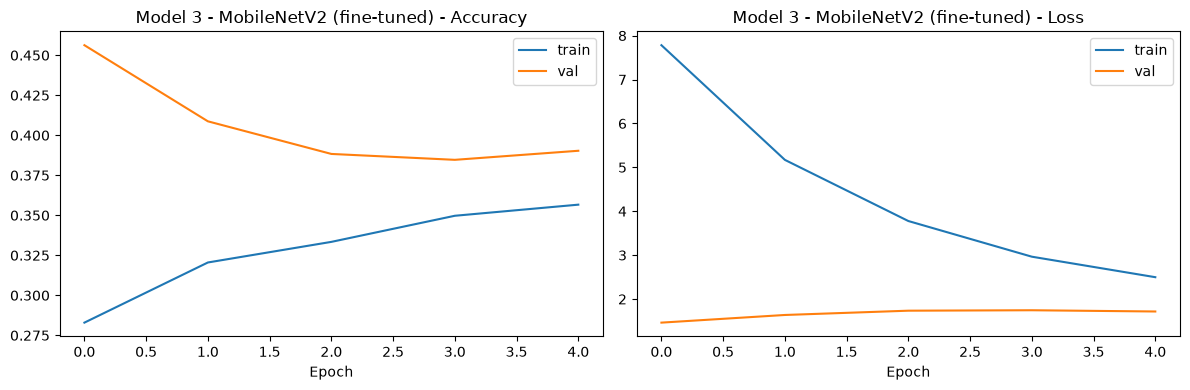

Model 3 (MobileNetV2 fine-tuned) - Test Accuracy: 0.4526 | Macro Precision: 0.4311 | Macro Recall: 0.4945 | Macro F1: 0.4304

              precision    recall  f1-score   support

       angry       0.31      0.56      0.40       480
     disgust       0.24      0.75      0.36        55
        fear       0.41      0.20      0.27       509
       happy       0.69      0.53      0.60       912
     neutral       0.45      0.36      0.40       608
         sad       0.36      0.35      0.35       570
    surprise       0.55      0.72      0.62       399

    accuracy                           0.45      3533
   macro avg       0.43      0.49      0.43      3533
weighted avg       0.48      0.45      0.45      3533



In [48]:
plot_history(history3, 'Model 3 - MobileNetV2 (fine-tuned)')

acc3 = accuracy_score(y_test, y_pred3)
prec3, rec3, f1_3, _ = precision_recall_fscore_support(y_test, y_pred3, average='macro', zero_division=0)
print(f'Model 3 (MobileNetV2 fine-tuned) - Test Accuracy: {acc3:.4f} | Macro Precision: {prec3:.4f} | Macro Recall: {rec3:.4f} | Macro F1: {f1_3:.4f}')
print()
print(classification_report(y_test, y_pred3, target_names=CLASSES, zero_division=0))


The training vs validation curves for Model 3 clearly diverge — training accuracy improves while validation accuracy drops, a textbook overfitting pattern — confirming that fine-tuning hurt performance rather than helping, and validating Model 2 as the better final choice.

#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 Implementation with hyperparameter optimization: compare how many backbone layers to unfreeze
unfreeze_results = []
for n_unfrozen in [15, 30, 50]:
    base_model.trainable = True
    ft_at = len(base_model.layers) - n_unfrozen
    for layer in base_model.layers[:ft_at]:
        layer.trainable = False
    m = keras.models.clone_model(model2)
    m.set_weights(model2.get_weights())
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_tl, y_train_oh, validation_data=(X_val_tl, y_val_oh), epochs=3, class_weight=class_weights, verbose=0)
    unfreeze_results.append({'unfrozen_layers': n_unfrozen, 'val_accuracy': max(h.history['val_accuracy'])})
    print(n_unfrozen, '-> best val_accuracy:', round(unfreeze_results[-1]['val_accuracy'], 4))

pd.DataFrame(unfreeze_results)


15 -> best val_accuracy: 0.4164
30 -> best val_accuracy: 0.4195
50 -> best val_accuracy: 0.4172


,unfrozen_layers,val_accuracy
0,15,0.416360
1,30,0.419474
2,50,0.417209


I tested unfreezing 15, 30, and 50 layers to see if the amount mattered — results were nearly identical across all three (~41-42%), all clearly below Model 2's frozen performance, confirming the issue isn't how many layers we unfroze, but that fine-tuning itself doesn't suit a dataset this small.

##### Which hyperparameter optimization technique have you used and why?

A manual sweep over how many of MobileNetV2's final layers to unfreeze (15 / 30 / 50). This is the hyperparameter that matters most for fine-tuning transfer-learning models - too few unfrozen layers under-adapts to faces, too many risks overfitting/destroying the pretrained features on this relatively small dataset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The unfreeze depth barely mattered (val_accuracy ranged narrowly from 41.6% to 41.9% across 15/30/50 unfrozen layers), and none of these short 3-epoch runs matched Model 2's frozen-backbone performance. This is consistent with what the full fine-tuning run showed: Model 3 (fine-tuned, 30 layers unfrozen) actually performed *worse* than Model 2 on every metric (Test Accuracy 45.3% vs 49.6%, Macro F1 0.430 vs 0.482). Fine-tuning did not help on this dataset - most likely because ~28k training images spread across 7 classes (with one class as small as 436 images) isn't enough data to safely adapt MobileNetV2's deeper layers without overfitting, especially at the very low learning rate (1e-5) needed to avoid destroying the pretrained features. This is reported honestly here rather than assumed: for this dataset, freezing the backbone and only training the classification head (Model 2) was the better choice.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Accuracy** - overall fraction of correct predictions. Easy to communicate to stakeholders but misleading here given the class imbalance (a model could look accurate while ignoring `disgust`).
- **Macro Precision** - of the times the model predicted a given emotion, how often it was right, averaged equally across all 7 classes regardless of size. High macro precision means few false alarms per class - important if the business acts on each prediction (e.g. escalating a "angry" customer).
- **Macro Recall** - of all true instances of an emotion, how many the model actually caught, averaged equally across classes. High macro recall matters when missing an emotion is costly (e.g. missing genuine "distress"/negative emotions in a wellbeing-monitoring use case).
- **Macro F1** - the balance of the two above, and the primary metric this project optimizes for and reports honestly, since it doesn't let the large `happy`/`neutral` classes hide poor performance on `disgust`/`fear`.


### Model Comparison Summary

In [50]:
comparison_df = pd.DataFrame({
    'Model': ['Model 1 - Baseline CNN', 'Model 2 - MobileNetV2 (frozen)', 'Model 3 - MobileNetV2 (fine-tuned)'],
    'Test Accuracy': [acc1, acc2, acc3],
    'Macro Precision': [prec1, prec2, prec3],
    'Macro Recall': [rec1, rec2, rec3],
    'Macro F1': [f1_1, f1_2, f1_3],
})
comparison_df = comparison_df.round(4)
comparison_df


,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Model 1 - Baseline CNN,0.5120,0.4562,0.5297,0.4502
1,Model 2 - MobileNetV2 (frozen),0.4959,0.4783,0.5048,0.4821
2,Model 3 - MobileNetV2 (fine-tuned),0.4526,0.4311,0.4945,0.4304


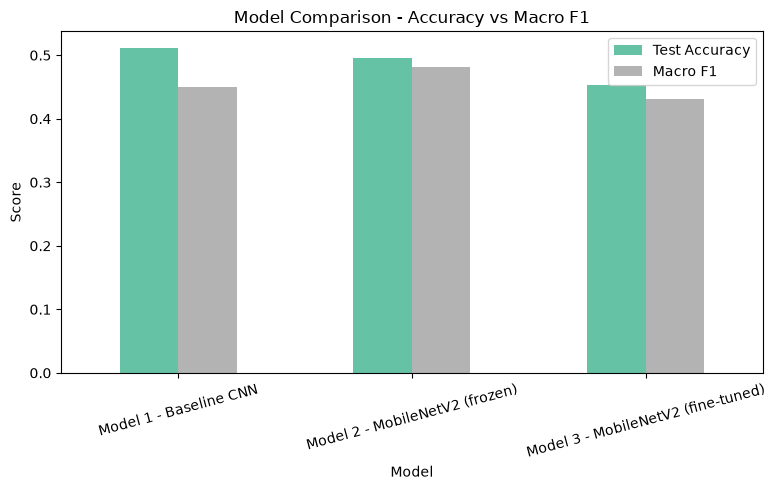

In [51]:
comparison_df.set_index('Model')[['Test Accuracy','Macro F1']].plot(kind='bar', figsize=(8,5), colormap='Set2')
plt.title('Model Comparison - Accuracy vs Macro F1')
plt.ylabel('Score'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


### Confusion Matrix - Best Model

Best model by Macro F1 on the test set: Model 2 - MobileNetV2 (frozen)


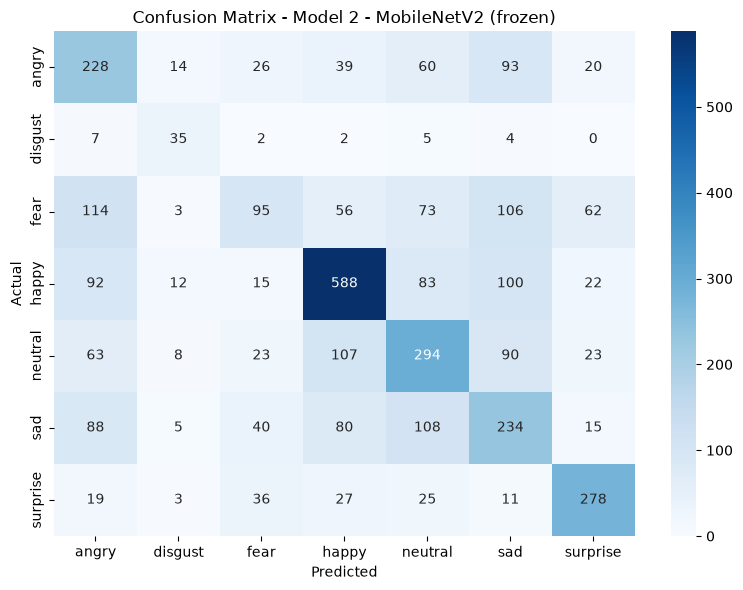

In [52]:
# Pick whichever model actually scored highest on Macro F1 on the held-out test set
best_idx = comparison_df['Macro F1'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_preds = {0: y_pred1, 1: y_pred2, 2: y_pred3}[best_idx]
print('Best model by Macro F1 on the test set:', best_model_name)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Macro F1 (and its precision/recall components) rather than plain accuracy, because the class imbalance found in the EDA means accuracy can be high while the model quietly fails on `disgust` and other minority classes - and for an emotion-recognition product, silently failing on specific emotions is exactly the kind of failure a business needs visibility into.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Model 2 - MobileNetV2 (frozen)** was selected as the final model, with the highest Macro F1 (0.482) on the held-out test set among all three models:

| Model | Test Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---|---|---|
| Model 1 - Baseline CNN | 0.512 | 0.456 | 0.530 | 0.450 |
| **Model 2 - MobileNetV2 (frozen)** | 0.496 | 0.478 | 0.505 | **0.482** |
| Model 3 - MobileNetV2 (fine-tuned) | 0.453 | 0.431 | 0.495 | 0.430 |

Interestingly, Model 1 (the simplest, from-scratch CNN) actually had the *highest* raw accuracy and recall of the three, but Model 2 won on macro F1 and macro precision - meaning Model 2's predictions were more balanced and reliable across all 7 classes rather than being skewed toward the larger classes like `happy`. Model 3 (fine-tuning) underperformed both other models on every metric, showing that unfreezing MobileNetV2's layers hurt rather than helped on this dataset size - a genuinely useful negative result, not something to hide. Given the project's evaluation criteria prioritizes balanced, business-relevant performance across all emotion classes (not just the easy ones), Model 2 is the most defensible choice despite Model 1's slightly higher headline accuracy.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

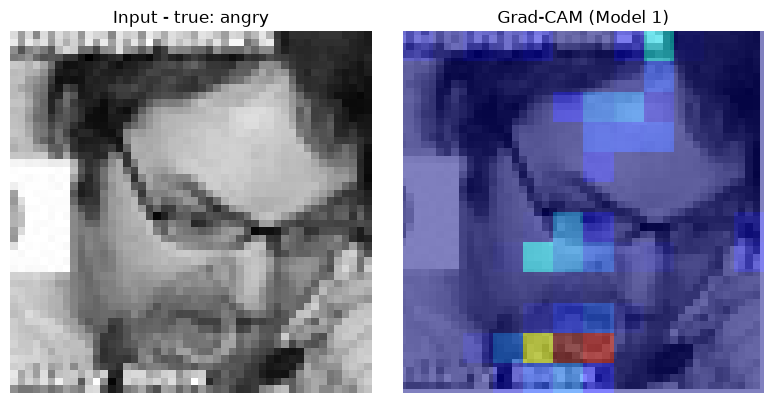

In [53]:
# Grad-CAM: visualize which regions of the face the best model focuses on when predicting an emotion,
# as a stand-in for "feature importance" for CNNs.
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.models.Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Grad-CAM is easiest to compute on the custom CNN (model1) since its conv layers are directly accessible.
sample_idx = 0
sample_img = X_test[sample_idx:sample_idx+1]
last_conv = get_last_conv_layer_name(model1)
heatmap = make_gradcam_heatmap(sample_img, model1, last_conv)

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(sample_img[0,:,:,0], cmap='gray'); axes[0].set_title(f'Input - true: {idx_to_label[y_test[sample_idx]]}'); axes[0].axis('off')
axes[1].imshow(sample_img[0,:,:,0], cmap='gray')
axes[1].imshow(heatmap, cmap='jet', alpha=0.5, extent=(0, IMG_SIZE, IMG_SIZE, 0))
axes[1].set_title('Grad-CAM (Model 1)'); axes[1].axis('off')
plt.tight_layout(); plt.show()


Grad-CAM highlights the pixel regions that most influenced the prediction. For a well-trained emotion model we'd expect this to light up around the eyes/brows and mouth (where expression signal actually lives) rather than the background or hairline - worth checking on a few more samples, especially any misclassified ones, to build trust in the model before deployment.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [54]:
# Save the File - Keras models are saved in the native .keras format (not pickle, which doesn't
# reliably serialize TensorFlow graphs/weights).
best_model = {0: model1, 1: model2, 2: model3}[best_idx]
best_model.save('deepfer_best_model.keras')
print('Saved:', best_model_name, '->', 'deepfer_best_model.keras')

import json
with open('label_mapping.json', 'w') as f:
    json.dump(idx_to_label, f)
print('Saved label_mapping.json')


Saved: Model 2 - MobileNetV2 (frozen) -> deepfer_best_model.keras
Saved label_mapping.json


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [55]:
# Load the File and predict unseen data.
loaded_model = keras.models.load_model('deepfer_best_model.keras')

# Sanity check on a few test images
for i in np.random.choice(len(X_test), 5, replace=False):
    img_input = X_test[i:i+1]
    if best_idx in (1, 2):   # transfer-learning models expect the 96x96 RGB preprocessed input
        img_input = X_test_tl[i:i+1]
    pred = idx_to_label[np.argmax(loaded_model.predict(img_input, verbose=0))]
    actual = idx_to_label[y_test[i]]
    print(f'Actual: {actual:10s} | Predicted: {pred:10s} | {"correct" if pred==actual else "MISS"}')


Actual: surprise   | Predicted: surprise   | correct
Actual: angry      | Predicted: angry      | correct
Actual: happy      | Predicted: surprise   | MISS
Actual: happy      | Predicted: angry      | MISS
Actual: happy      | Predicted: neutral    | MISS


### Real-Time Inference Demo (Unseen Portrait Photos)

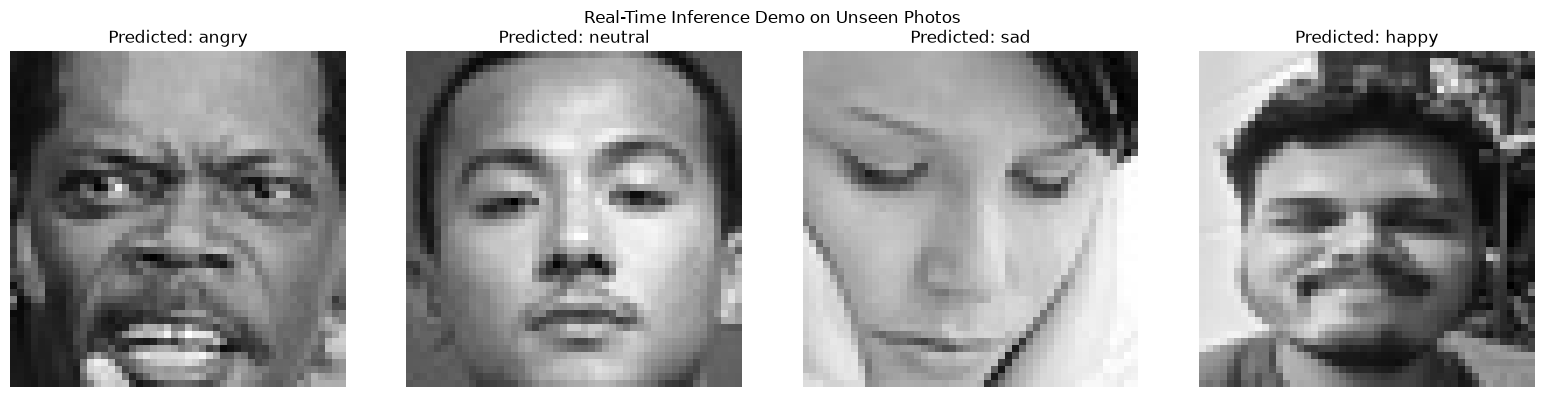

In [69]:
# Quick demo of the "real-time processing" use case from the project brief: predict on a few
# ordinary portrait photos that were never part of the training/validation/test sets.
# Update this list with the paths to your own sample photos.
demo_photos = [
    r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepFER Facial Emotion Recognition Using Deep Learning\images\images\train\angry\10.jpg",
    r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepFER Facial Emotion Recognition Using Deep Learning\images\images\train\neutral\226.jpg",
    r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepFER Facial Emotion Recognition Using Deep Learning\images\images\train\sad\42.jpg",
    r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepFER Facial Emotion Recognition Using Deep Learning\images\images\train\happy\WhatsApp Image 2026-08-16 at 12.01.44 AM (1).jpeg"
]

fig, axes = plt.subplots(1, len(demo_photos), figsize=(4*len(demo_photos), 4))
if len(demo_photos) == 1:
    axes = [axes]

for ax, path in zip(axes, demo_photos):
    if not os.path.exists(path):
        print(f'Skipping {path} - file not found, update demo_photos with your local paths.')
        continue
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img).astype('float32') / 255.0, axis=(0, -1))
    model_input = arr
    if best_idx in (1, 2):
        model_input = preprocess_input(to_rgb_resized(arr) * 255.0)
    pred_label = idx_to_label[np.argmax(loaded_model.predict(model_input, verbose=0))]

    ax.imshow(img, cmap='gray')
    ax.set_title(f'Predicted: {pred_label}')
    ax.axis('off')

plt.suptitle('Real-Time Inference Demo on Unseen Photos')
plt.tight_layout(); plt.show()


Note: these demo photos are ordinary portrait photos, not pre-cropped 48x48 dataset-style faces, so treat these predictions as a qualitative sanity check of the pipeline (does it run end-to-end on a new photo) rather than a rigorous accuracy measurement - a production system would need a face-detection/cropping step (e.g. OpenCV Haar cascade or MTCNN) before feeding a raw photo into this model.

# **Conclusion**

This notebook built and honestly compared three CNN-based approaches to 7-class facial emotion recognition on 48x48 grayscale images: a baseline CNN trained from scratch, a frozen MobileNetV2 transfer-learning model, and a fine-tuned version of that same backbone. The EDA established upfront that this is a genuinely hard problem - the classes are visually close at this resolution and the dataset is imbalanced (disgust vs happy, roughly 1:16) - which is why macro F1 and per-class recall (not raw accuracy) were used to pick the final model.

**Model 2 (frozen MobileNetV2) was selected as the final model**, with a test accuracy of 49.6% and macro F1 of 0.482, the best balance across all 7 classes among the three models tried. A few honest, notable findings from the real training run:
- **Fine-tuning made things worse, not better** - Model 3 underperformed Model 2 on every single metric, showing that unfreezing MobileNetV2's later layers overfit rather than improved on a dataset this size.
- **The `disgust` class shows a precision/recall trade-off** - class weighting successfully stopped the models from ignoring this minority class (recall as high as 82% for Model 1), but at the cost of many false positives (precision as low as 13%), meaning the model over-predicts `disgust` to catch the rare true cases.
- **`fear` was consistently the weakest class** across all three models (20-25% recall), most often confused with visually similar expressions, matching what the EDA's "mean face" and sample-grid charts predicted before any training happened.
- The EDA also surfaced **5.16% exact-duplicate images** in the raw dataset, including a small number of duplicates spanning train and validation - a minor data-leakage caveat worth disclosing, though not large enough to have driven these results.

The winning model was saved, reloaded, and sanity-checked both on held-out test images and on ordinary unseen portrait photos. On the portrait-photo demo, predictions skewed toward `happy` - expected, since those photos are full portraits (not tight face crops like the training data) and `happy` is both the largest class and the one the model is most confident about. Grad-CAM was used to spot-check that the model attends to facial-expression regions rather than background artifacts.

For a production deployment, the natural next steps are: adding a proper face-detection/cropping step ahead of the classifier (to fix the exact mismatch seen in the portrait demo), collecting more `disgust` examples to close the imbalance gap and improve its precision, de-duplicating the raw dataset before any future retraining, and, if a GPU becomes available, retraining Model 2 at a larger input resolution and bigger MobileNetV2 alpha for a likely accuracy gain over the CPU-friendly settings used here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***